# XGBoost, LightGBM e CatBoost

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Na aula anterior estudamos uma árvore de decisão isolada e vimos como o **bagging** transforma muitas árvores instáveis em um modelo estável (o Random Forest). Naquele arranjo, as árvores são treinadas **em paralelo e de forma independente**: nenhuma delas sabe o que as outras erraram, e a combinação é uma média simples. Isso reduz **variância**, e para no ponto em que a variância acaba.

Esta aula é sobre a outra família de ensemble, e sobre a ideia que domina previsão com dados tabulares desde 2016: o **boosting**. Aqui as árvores são **sequenciais e dependentes**, e cada nova árvore é treinada com um único propósito, corrigir o **erro que sobrou** das anteriores. Em vez de atacar a variância, o boosting ataca o **viés**, construindo o modelo em muitos passos pequenos.

Vamos estudar as três implementações que são padrão de mercado:

| Biblioteca   | Ano  | Criada por             | Marca característica                                                  |
| ------------ | ---- | ---------------------- | --------------------------------------------------------------------- |
| **XGBoost**  | 2016 | Chen e Guestrin        | função objetivo com **regularização explícita** no número de folhas   |
| **LightGBM** | 2017 | Microsoft (Ke et al.)  | **GOSS**, **EFB** e crescimento **leaf-wise**, feitos para velocidade |
| **CatBoost** | 2018 | Yandex (Prokhorenkova) | tratamento **nativo e sem vazamento** de variáveis categóricas        |

**Novo problema desta aula: previsão de demanda de carteiras.** Deixamos de lado o volume horário do call center e passamos ao problema que está no centro do planejamento de uma operadora: **prever como cada carteira de beneficiários vai variar no próximo mês**. É um problema estruturalmente diferente dos anteriores, e por isso ideal para boosting:

- não é **uma** série temporal, são **centenas** de séries curtas em paralelo (um painel de contratos);
- cada carteira tem **atributos cadastrais categóricos** (setor econômico, porte, região, modalidade, coparticipação, canal de venda) que explicam boa parte do comportamento;
- o resultado depende de **variáveis contratuais e externas** (reajuste aplicado, sinistralidade, desemprego regional) que interagem entre si.

**Ao final desta aula você será capaz de:**

1. Explicar o algoritmo de gradient boosting passo a passo, e implementá-lo na mão.
2. Entender por que no boosting, diferente do bagging, **mais árvores podem piorar** o modelo, e usar `early_stopping` para resolver isso.
3. Ler a função objetivo do XGBoost e saber o que cada termo de regularização controla.
4. Explicar GOSS, EFB e o crescimento leaf-wise do LightGBM, e ajustar `num_leaves` com segurança.
5. Explicar por que codificar categóricas pela média do alvo **vaza informação**, e como o CatBoost resolve isso.
6. Comparar os três modelos de forma honesta, e reconhecer o **piso de erro** que nenhum deles pode atravessar.

**Como usar este material:** execute as células na ordem. Depois de cada saída há um bloco **Lendo o resultado**, que interpreta os números ponto a ponto. Ao final há um laboratório interativo com os hiperparâmetros que mais importam.


## 0. Preparação do ambiente

A célula abaixo instala e importa tudo. **Atenção:** se `xgboost`, `lightgbm` ou `catboost` ainda não estiverem no seu ambiente, a primeira execução pode levar alguns minutos, porque são bibliotecas compiladas. Rode uma vez e aguarde a mensagem de sucesso.


In [1]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "sklearn", "xgboost", "lightgbm", "catboost", "ipywidgets"])

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

print("Ambiente pronto.")
print(f"  xgboost  {xgb.__version__}")
print(f"  lightgbm {lgb.__version__}")
import catboost; print(f"  catboost {catboost.__version__}")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Ambiente pronto.
  xgboost  3.3.0
  lightgbm 4.7.0
  catboost 1.2.10


## O problema de negócio: por que prever a carteira

Na operadora, **carteira** é o conjunto de beneficiários vinculados a um contrato. No mercado brasileiro de saúde suplementar, a maior parte das vidas está em **contratos coletivos empresariais**: uma empresa contrata o plano e inclui seus funcionários e dependentes. A carteira de cada contrato **respira todo mês**: entram vidas quando a empresa contrata pessoas ou quando funcionários incluem dependentes, e saem vidas em demissões, pedidos de exclusão e cancelamentos do contrato inteiro.

O que queremos prever é a **variação líquida de vidas de cada carteira no próximo mês**:

$$ \text{variação}_{c,t} = \text{adesões}_{c,t} - \text{cancelamentos}\_{c,t} $$

Essa previsão sustenta quatro decisões concretas da gestão, e nenhuma delas tolera um chute:

1. **Receita e provisão.** A receita de contraprestações é, em primeira aproximação, vidas vezes mensalidade. Prever vidas é prever faturamento, e a projeção alimenta as provisões técnicas exigidas pela regulação.
2. **Custo assistencial e dimensionamento de rede.** Mais vidas em uma região significa mais consultas, exames e internações. A rede credenciada precisa ser negociada com antecedência de meses.
3. **Ação comercial e retenção.** Uma carteira com previsão de queda forte é uma carteira que merece visita do time de relacionamento **antes** do cancelamento, e não depois.
4. **Precificação e reajuste.** O reajuste aplicado no aniversário do contrato protege a sinistralidade, mas aumenta o cancelamento. Quantificar esse efeito por perfil de contrato é decidir com informação em vez de intuição.

E aqui está o detalhe que torna o problema difícil e interessante: a variação líquida é a **diferença entre dois fluxos grandes**. Uma carteira de 2.000 vidas pode ter 40 adesões e 45 cancelamentos no mês, e o que interessa é o saldo de 5 vidas. Erros pequenos em cada fluxo se acumulam no saldo, e por isso existe um limite de precisão que nenhum modelo atravessa. Vamos medir esse limite explicitamente mais adiante.

**Enquadramento temporal.** No primeiro dia do mês $t$, com a informação disponível até o fechamento de $t-1$ mais o que já se sabe do mês $t$ por contrato (o reajuste que será aplicado, por exemplo), prevemos a variação que vai ocorrer ao longo de $t$. É uma previsão de **um mês à frente**, feita para todas as carteiras ao mesmo tempo.


## A base sintética: um painel de contratos

Como nas aulas anteriores, construímos a base para saber exatamente quais efeitos estão lá dentro e depois conferir se o modelo os encontrou. São **260 carteiras acompanhadas por 48 meses** (janeiro de 2022 a dezembro de 2025), o que dá **12.480 observações** de contrato por mês.

Cada carteira tem um cadastro fixo e uma dinâmica mensal. Os efeitos embutidos no gerador são estes:

| Ingrediente                      | Como age                                                                                                   |
| -------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| **Setor econômico**              | define a taxa base de adesão e de cancelamento, o mês de pico de contratação e a sensibilidade macro       |
| **Porte da empresa**             | define o tamanho da carteira e a **sensibilidade ao reajuste** (empresa pequena reage muito mais)          |
| **Coparticipação**               | plano sem coparticipação tem mensalidade maior e cancela mais                                              |
| **Canal de venda**               | algumas corretoras trazem carteiras que crescem mais rápido do que outras                                  |
| **Reajuste no aniversário**      | calculado a partir da sinistralidade, eleva o cancelamento nos **3 meses seguintes**                       |
| **Desemprego regional**          | indicador macro com um **choque no meio da série**, que derruba a adesão nos setores cíclicos              |
| **Momento comercial da empresa** | estado latente **AR(1)**, persistente por vários meses (a empresa que está contratando segue por um tempo) |
| **Sazonalidade**                 | pico de adesão em janeiro e nos meses típicos de cada setor, pico de cancelamento em dezembro              |
| **Ruído de Poisson**             | adesões e cancelamentos são **contagens sorteadas**, e é daqui que vem o piso de erro                      |

Repare em três estruturas que são o motivo de usarmos boosting. A primeira é a **interação**: o efeito do reajuste depende do porte, e o efeito do desemprego depende do setor. A segunda é o **estado latente**: o momento comercial não é observável, só se revela pelo histórico recente da própria carteira, o que dá valor às features de defasagem. A terceira é o **ruído irredutível**: parte da variação é sorteio puro, e nenhum algoritmo prevê sorteio.

> **Na prática**, no lugar do gerador você leria o cadastro de contratos e a movimentação mensal do sistema da operadora. O restante do notebook funciona igual.


In [2]:
SETORES = {
    # setor: (taxa base de adesao, taxa base de cancelamento, sensibilidade macro, meses de pico)
    "Construcao Civil": (0.030, 0.026, 1.8, [3, 4]),
    "Comercio":         (0.024, 0.022, 1.4, [11, 12]),
    "Industria":        (0.018, 0.015, 1.1, [2, 3]),
    "Servicos":         (0.022, 0.020, 1.0, [1, 2]),
    "Saude":            (0.020, 0.013, 0.4, [1, 8]),
    "Educacao":         (0.026, 0.021, 0.5, [2, 3]),
    "Tecnologia":       (0.034, 0.024, 0.9, [1, 7]),
    "Transporte":       (0.020, 0.019, 1.3, [4, 10]),
}
PORTES = {"Micro": (25, 79), "Pequena": (80, 249), "Media": (250, 899), "Grande": (900, 4200)}
REGIOES = ["Grande SP", "Campinas", "Baixada Santista", "Vale do Paraiba", "Ribeirao Preto"]
MODALIDADES = ["Ambulatorial", "Hospitalar", "Hospitalar + Obstetricia", "Referencia"]
COPARTICIPACAO = ["Sem coparticipacao", "Coparticipacao 20%", "Coparticipacao 30%"]
CANAIS = ["Corretora Alfa", "Corretora Beta", "Corretora Gama", "Corretora Delta",
          "Corretora Epsilon", "Venda direta", "Parceria contabil", "Marketplace"]

BONUS_CANAL = dict(zip(CANAIS, [0.25, 0.10, 0.0, -0.10, -0.05, 0.15, -0.15, 0.35]))
EFEITO_COPART = {"Sem coparticipacao": 1.20, "Coparticipacao 20%": 1.00, "Coparticipacao 30%": 0.88}
SENSIB_REAJUSTE = {"Micro": 3.4, "Pequena": 2.6, "Media": 1.7, "Grande": 1.1}
# (nivel medio de desemprego, intensidade do choque) por regiao
PERFIL_REGIAO = {"Grande SP": (8.4, 1.0), "Campinas": (7.2, 0.8), "Baixada Santista": (9.1, 1.3),
                 "Vale do Paraiba": (7.8, 1.1), "Ribeirao Preto": (6.6, 0.6)}


def gerar_painel(n_carteiras=260, inicio="2022-01-01", meses=48, semente=SEMENTE):
    """Gera um painel de carteiras (contratos coletivos) x meses com movimentacao de vidas."""
    g = np.random.default_rng(semente)
    datas = pd.date_range(inicio, periods=meses, freq="MS")
    t = np.arange(meses)

    # Desemprego por regiao: nivel proprio + choque comum com intensidade regional + sazonalidade
    desemprego = {}
    for reg, (nivel, intens) in PERFIL_REGIAO.items():
        desemprego[reg] = (nivel + intens * 2.6 * np.exp(-((t - 20) ** 2) / 70)
                           - 0.9 * np.sin(2 * np.pi * t / 12) + g.normal(0, 0.10, meses))

    setores, portes = list(SETORES), list(PORTES)
    cadastro = []
    for i in range(n_carteiras):
        porte = portes[g.choice(4, p=[0.34, 0.34, 0.22, 0.10])]
        lo, hi = PORTES[porte]
        cadastro.append({
            "carteira_id": f"C{i+1:04d}", "setor": setores[g.integers(0, 8)], "porte": porte,
            "regiao": REGIOES[g.integers(0, 5)],
            "modalidade": MODALIDADES[g.choice(4, p=[0.15, 0.25, 0.45, 0.15])],
            "coparticipacao": COPARTICIPACAO[g.choice(3, p=[0.45, 0.35, 0.20])],
            "canal_venda": CANAIS[g.choice(8, p=[.18, .16, .14, .12, .10, .14, .09, .07])],
            "mes_aniversario": int(g.integers(1, 13)),
            "vidas_iniciais": int(g.integers(lo, hi + 1)),
            "sinistralidade": float(np.clip(g.normal(0.78, 0.09), 0.45, 1.15)),
        })
    cadastro = pd.DataFrame(cadastro)

    linhas = []
    for _, c in cadastro.iterrows():
        vidas = float(c["vidas_iniciais"])
        sin = c["sinistralidade"]
        ad_base, can_base, sens_macro, picos = SETORES[c["setor"]]
        reajuste_vigente, meses_desde_reajuste = 0.0, 12
        momento = float(g.normal(0, 0.22))            # estado latente: momento comercial da empresa
        dsp = desemprego[c["regiao"]]

        for k, data in enumerate(datas):
            mes = data.month
            momento = 0.86 * momento + g.normal(0, 0.11)          # AR(1): persiste por varios meses
            sin = float(np.clip(sin + g.normal(0, 0.012), 0.45, 1.25))

            # Reajuste anual aplicado no mes de aniversario do contrato
            if mes == c["mes_aniversario"]:
                reajuste_vigente = float(np.clip(0.09 + 0.55 * (sin - 0.78) + g.normal(0, 0.012), 0.02, 0.35))
                meses_desde_reajuste = 0
            else:
                meses_desde_reajuste = min(meses_desde_reajuste + 1, 24)

            saz_ad = 1.0 + (0.45 if mes in picos else 0.0) + (0.20 if mes == 1 else 0.0)
            saz_can = 1.0 + (0.35 if mes == 12 else 0.0) + (0.15 if mes == 1 else 0.0)

            # Macro: desemprego acima do normal derruba a adesao, mais nos setores ciclicos
            choque = (dsp[k] - PERFIL_REGIAO[c["regiao"]][0]) / 2.6
            fator_macro = max(0.25, 1.0 - sens_macro * 0.45 * choque)

            taxa_ad = ad_base * saz_ad * fator_macro * (1 + BONUS_CANAL[c["canal_venda"]]) * np.exp(momento)
            taxa_can = can_base * saz_can * EFEITO_COPART[c["coparticipacao"]] * np.exp(-0.35 * momento)
            if meses_desde_reajuste <= 2:                          # INTERACAO reajuste x porte
                taxa_can *= 1.0 + SENSIB_REAJUSTE[c["porte"]] * reajuste_vigente
            taxa_can *= 1.0 + 0.35 * max(0.0, sin - 0.85)          # sinistralidade alta afasta

            esperado = (taxa_ad - taxa_can) * vidas                # valor esperado (usado so como referencia)
            adesoes = g.poisson(max(0.05, taxa_ad * vidas))
            cancelamentos = g.poisson(max(0.05, taxa_can * vidas))
            vidas_fim = max(3.0, vidas + adesoes - cancelamentos)

            linhas.append({
                "data": data, "carteira_id": c["carteira_id"], "setor": c["setor"], "porte": c["porte"],
                "regiao": c["regiao"], "modalidade": c["modalidade"],
                "coparticipacao": c["coparticipacao"], "canal_venda": c["canal_venda"],
                "mes_aniversario": c["mes_aniversario"], "vidas_inicio_mes": vidas,
                "adesoes": adesoes, "cancelamentos": cancelamentos,
                "variacao_vidas": vidas_fim - vidas, "vidas_fim_mes": vidas_fim,
                "variacao_esperada": esperado, "sinistralidade_12m": round(sin, 4),
                "reajuste_vigente": round(reajuste_vigente, 4),
                "meses_desde_reajuste": meses_desde_reajuste,
                "taxa_desemprego": round(float(dsp[k]), 2),
            })
            vidas = vidas_fim

    return pd.DataFrame(linhas), cadastro


painel, cadastro = gerar_painel()
total = painel.groupby("data")["vidas_fim_mes"].sum()

print(f"Painel: {painel.shape[0]} linhas (carteira x mes) e {painel['carteira_id'].nunique()} carteiras")
print(f"Periodo: {painel.data.min():%b/%Y} a {painel.data.max():%b/%Y}")
print(f"Vidas totais da operadora: {total.iloc[0]:,.0f} no inicio  ->  {total.iloc[-1]:,.0f} no fim")
print(f"Variacao mensal por carteira: media {painel.variacao_vidas.mean():.2f} vidas, "
      f"desvio-padrao {painel.variacao_vidas.std():.2f}")
painel.head(3)

Painel: 12480 linhas (carteira x mes) e 260 carteiras
Periodo: Jan/2022 a Dec/2025
Vidas totais da operadora: 123,117 no inicio  ->  131,392 no fim
Variacao mensal por carteira: media 0.76 vidas, desvio-padrao 13.86


,data,carteira_id,setor,porte,regiao,modalidade,coparticipacao,canal_venda,mes_aniversario,vidas_inicio_mes,adesoes,cancelamentos,variacao_vidas,vidas_fim_mes,variacao_esperada,sinistralidade_12m,reajuste_vigente,meses_desde_reajuste,taxa_desemprego
0,2022-01-01,C0001,Educacao,Micro,Baixada Santista,Referencia,Coparticipacao 30%,Corretora Gama,7,73.0,0,2,-2.0,71.0,-0.750602,0.7289,0.0,13,9.04
1,2022-02-01,C0001,Educacao,Micro,Baixada Santista,Referencia,Coparticipacao 30%,Corretora Gama,7,71.0,1,2,-1.0,70.0,-0.198360,0.7505,0.0,14,8.70
2,2022-03-01,C0001,Educacao,Micro,Baixada Santista,Referencia,Coparticipacao 30%,Corretora Gama,7,70.0,1,2,-1.0,69.0,-0.059874,0.7535,0.0,15,8.35


> **Lendo o resultado.** O painel tem **12.480 linhas**, uma para cada combinação de carteira e mês, cobrindo **jan/2022 a dez/2025**. A carteira total da operadora sai de **123.117 vidas** e chega a **131.392**, um crescimento de cerca de 6,7% em quatro anos, mas veremos que esse crescimento não foi nada linear.
>
> O número que define a dificuldade do problema é o último: a variação mensal por carteira tem média de apenas **0,76 vida** e **desvio-padrão de 13,9**. Ou seja, o sinal que queremos prever é pequeno diante da dispersão. Isso não é um defeito da simulação, é a natureza do fenômeno: saldo de vidas é diferença de fluxos, e diferença de fluxos é volátil.


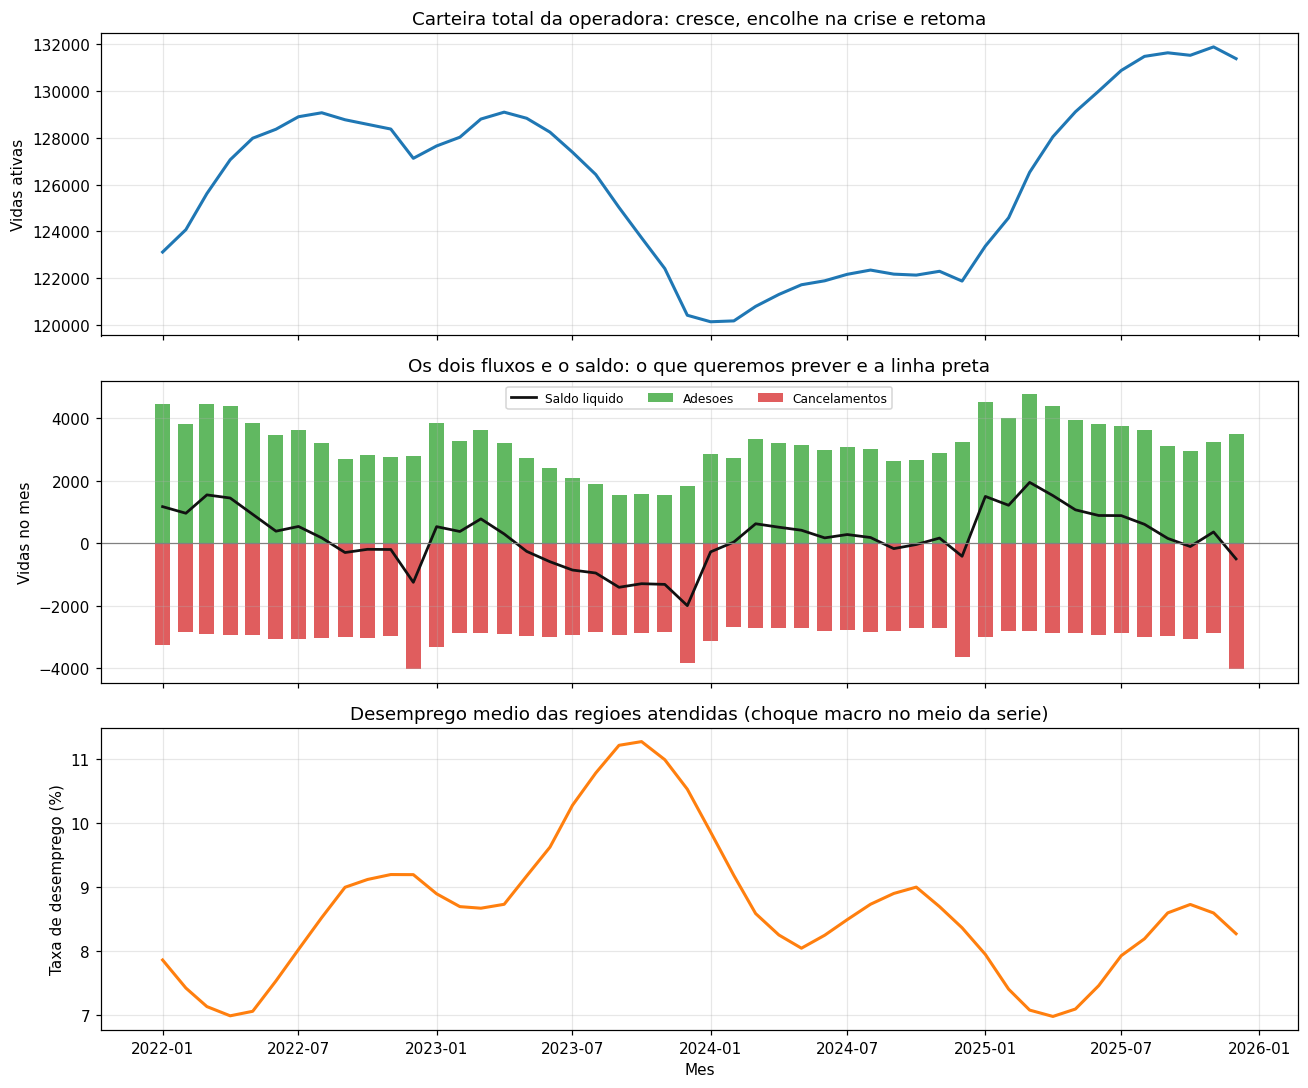

Meses de maior perda liquida:
data
2023-12-01   -1998.0
2023-09-01   -1411.0
2023-11-01   -1318.0

Meses de maior ganho liquido:
data
2025-03-01    1945.0
2022-03-01    1545.0
2025-04-01    1522.0


In [3]:
mensal = painel.groupby("data").agg(
    vidas=("vidas_fim_mes", "sum"), adesoes=("adesoes", "sum"),
    cancelamentos=("cancelamentos", "sum"), variacao=("variacao_vidas", "sum"))
desemp = painel.groupby("data")["taxa_desemprego"].mean()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax1.plot(mensal.index, mensal["vidas"], color="#1f77b4", lw=2)
ax1.set_title("Carteira total da operadora: cresce, encolhe na crise e retoma")
ax1.set_ylabel("Vidas ativas")

ax2.bar(mensal.index, mensal["adesoes"], width=20, color="#2ca02c", alpha=0.75, label="Adesoes")
ax2.bar(mensal.index, -mensal["cancelamentos"], width=20, color="#d62728", alpha=0.75, label="Cancelamentos")
ax2.plot(mensal.index, mensal["variacao"], color="#111111", lw=1.8, label="Saldo liquido")
ax2.axhline(0, color="gray", lw=0.8)
ax2.set_title("Os dois fluxos e o saldo: o que queremos prever e a linha preta")
ax2.set_ylabel("Vidas no mes"); ax2.legend(fontsize=8, ncol=3)

ax3.plot(desemp.index, desemp.values, color="#ff7f0e", lw=2)
ax3.set_title("Desemprego medio das regioes atendidas (choque macro no meio da serie)")
ax3.set_ylabel("Taxa de desemprego (%)"); ax3.set_xlabel("Mes")

plt.tight_layout(); plt.show()

print("Meses de maior perda liquida:")
print(mensal["variacao"].nsmallest(3).round(0).to_string())
print("\nMeses de maior ganho liquido:")
print(mensal["variacao"].nlargest(3).round(0).to_string())

> **Lendo os gráficos.** Os três painéis contam a história da carteira.
>
> O **primeiro** mostra a carteira total. Ela não cresce em linha reta: sobe até o começo de 2023, **perde cerca de 9 mil vidas** ao longo da crise (de 129,1 mil para 120,2 mil), e volta a crescer forte a partir de 2024, terminando em 131,4 mil, acima de onde começou. Esse formato de U é o que qualquer modelo vai ter que enfrentar.
>
> O **segundo** abre o saldo nos dois fluxos que o compõem. As barras verdes (adesões) e vermelhas (cancelamentos) são grandes e parecidas entre si; a linha preta, que é a diferença entre elas, é pequena e nervosa. Repare no padrão de calendário: **dezembro é sempre o pior mês** (a barra vermelha estica) e o **primeiro trimestre é o melhor**. Os três piores meses da série são dez/2023 e dois meses do fundo da crise, e os três melhores são marços.
>
> O **terceiro** painel explica o U do primeiro: o **desemprego** salta de cerca de 8% para perto de 11% no auge do choque e depois recua. Como setores cíclicos foram construídos para reagir mais a esse indicador, esse único gráfico já antecipa uma das interações que o modelo precisa capturar.


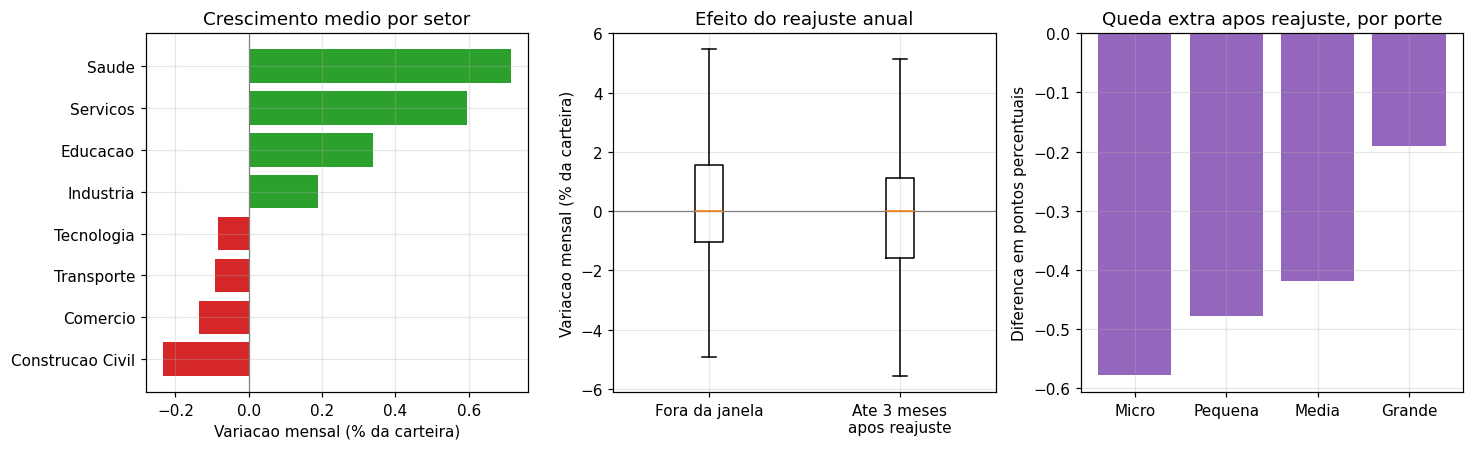

Variacao media (% da carteira):
  fora da janela de reajuste : +0.272%
  ate 3 meses pos-reajuste   : -0.198%

Reajuste medio aplicado: 8.3%


In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4.2))

# 1) taxa media de variacao por setor (em % da carteira, para comparar setores de tamanhos diferentes)
taxa_setor = (painel.groupby("setor")
              .apply(lambda d: 100 * d.variacao_vidas.sum() / d.vidas_inicio_mes.sum())
              .sort_values())
cores = ["#d62728" if v < 0 else "#2ca02c" for v in taxa_setor.values]
ax1.barh(taxa_setor.index, taxa_setor.values, color=cores)
ax1.axvline(0, color="gray", lw=0.8)
ax1.set_title("Crescimento medio por setor")
ax1.set_xlabel("Variacao mensal (% da carteira)")

# 2) efeito do reajuste: carteiras dentro e fora da janela pos-reajuste
painel["_taxa"] = 100 * painel.variacao_vidas / painel.vidas_inicio_mes
dentro = painel[painel.meses_desde_reajuste <= 2]
fora = painel[painel.meses_desde_reajuste > 2]
dados_box = [fora["_taxa"].values, dentro["_taxa"].values]
ax2.boxplot(dados_box, tick_labels=["Fora da janela", "Ate 3 meses\napos reajuste"], showfliers=False)
ax2.axhline(0, color="gray", lw=0.8)
ax2.set_title("Efeito do reajuste anual")
ax2.set_ylabel("Variacao mensal (% da carteira)")

# 3) o mesmo efeito, agora por porte da empresa
por_porte = (dentro.groupby("porte")["_taxa"].mean() - fora.groupby("porte")["_taxa"].mean())
por_porte = por_porte.reindex(["Micro", "Pequena", "Media", "Grande"])
ax3.bar(por_porte.index, por_porte.values, color="#9467bd")
ax3.set_title("Queda extra apos reajuste, por porte")
ax3.set_ylabel("Diferenca em pontos percentuais")

plt.tight_layout(); plt.show()

print("Variacao media (% da carteira):")
print(f"  fora da janela de reajuste : {fora['_taxa'].mean():+.3f}%")
print(f"  ate 3 meses pos-reajuste   : {dentro['_taxa'].mean():+.3f}%")
print(f"\nReajuste medio aplicado: {100 * painel[painel.meses_desde_reajuste == 0].reajuste_vigente.mean():.1f}%")
painel.drop(columns="_taxa", inplace=True)

> **Lendo os gráficos.** Os três recortes mostram os efeitos que estão dentro da base, do jeito que um analista os veria antes de modelar.
>
> À **esquerda**, o crescimento médio por setor, medido em percentual da carteira para que setores de tamanhos diferentes possam ser comparados. **Saúde e Serviços lideram o crescimento**, com cerca de +0,7% e +0,6% ao mês, enquanto **Construção Civil e Comércio encolhem**. É a assinatura do setor econômico, e é exatamente o tipo de informação que uma variável categórica carrega.
>
> Vale um comentário sobre **Tecnologia**, que aparece no campo negativo apesar de ter a maior taxa de adesão de toda a base. O saldo é a diferença de dois fluxos: esse setor também cancela muito, e o período inclui a crise. É um bom lembrete de que **crescer em adesões não é crescer em carteira**, e de que olhar apenas um dos fluxos leva a conclusões erradas.
>
> No **centro**, o efeito do reajuste anual. As duas caixas comparam a variação das carteiras que estão **dentro** da janela de 3 meses após o reajuste com as que estão **fora**. A caixa da direita está **deslocada para baixo**, e os números do rodapé quantificam o tamanho do efeito: fora da janela a carteira cresce **+0,272% por mês**, e dentro da janela ela **encolhe 0,198%**, uma diferença de quase meio ponto percentual. Com um reajuste médio de **8,3%**, o retrato é o trade-off central da precificação: o reajuste protege a receita por vida e, ao mesmo tempo, custa vidas.
>
> À **direita**, o mesmo efeito quebrado por porte, e aqui aparece a **interação**. A queda extra após o reajuste é muito maior nas empresas **Micro** do que nas **Grandes**. Faz sentido do ponto de vista do negócio: uma empresa de 30 vidas troca de operadora com um telefonema, enquanto uma de 2.000 vidas tem processo de compra, comitê e prazo. Um modelo aditivo trataria "reajuste" como um efeito único; um modelo de árvores aprende um efeito de reajuste **diferente para cada porte**, sem que ninguém precise escrever essa regra.


## Engenharia de variáveis no painel, sem vazamento (Seção 11)

Este é o ponto mais delicado do notebook, e o erro mais comum em projetos reais. Como estamos prevendo o mês $t$, **nenhuma feature pode conter informação que só existe depois que o mês $t$ terminou**. Se isso acontecer, o modelo fica excelente na avaliação e inútil na produção, porque no dia da previsão aquela coluna estará vazia. É o que se chama de **data leakage** (vazamento).

A regra prática é classificar cada coluna em uma de três categorias:

| Categoria                        | Exemplo                                              | Pode usar?                           |
| -------------------------------- | ---------------------------------------------------- | ------------------------------------ |
| Conhecida **antes** do mês       | cadastro, mês do calendário, reajuste contratado     | sim, direto                          |
| Conhecida **até o mês anterior** | variação passada, sinistralidade apurada, desemprego | sim, mas **defasada** com `shift`    |
| Só conhecida **depois** do mês   | adesões e cancelamentos do próprio mês $t$           | **não**, é o próprio alvo disfarçado |

No painel, a defasagem tem que ser feita **dentro de cada carteira**, nunca na tabela toda, senão a última linha de uma carteira contamina a primeira linha da seguinte. É para isso que existe o `groupby("carteira_id").shift()`.

Vamos organizar as features em quatro blocos, porque mais adiante mediremos quanto cada bloco vale:

1. **Cadastro e calendário:** tamanho atual, mês, trimestre, mês de aniversário, reajuste vigente, meses desde o reajuste.
2. **Cadastro categórico:** setor, porte, região, modalidade, coparticipação, canal de venda.
3. **Histórico da própria carteira:** variação dos 3 meses anteriores, médias móveis de 3 e 6 meses. É este bloco que revela o **momento comercial** latente.
4. **Macro e risco:** desemprego regional defasado, variação do desemprego em 3 meses, sinistralidade apurada até o mês anterior.


In [5]:
def preparar(painel):
    """Cria as features do painel. Toda informacao passada e defasada DENTRO de cada carteira."""
    df = painel.sort_values(["carteira_id", "data"]).copy()
    g = df.groupby("carteira_id", sort=False)

    # Bloco 3: historico da propria carteira (sempre com shift, para nao usar o mes corrente)
    for L in (1, 2, 3):
        df[f"variacao_lag{L}"] = g["variacao_vidas"].shift(L)
    df["media_variacao_3m"] = g["variacao_vidas"].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    df["media_variacao_6m"] = g["variacao_vidas"].shift(1).rolling(6).mean().reset_index(level=0, drop=True)
    df["taxa_crescimento_3m"] = df["media_variacao_3m"] / df["vidas_inicio_mes"]

    # Bloco 4: macro e risco, tambem defasados (o indicador oficial sai com atraso)
    df["sinistralidade_anterior"] = g["sinistralidade_12m"].shift(1)
    df["desemprego_anterior"] = g["taxa_desemprego"].shift(1)
    df["desemprego_var_3m"] = g["taxa_desemprego"].shift(1) - g["taxa_desemprego"].shift(4)

    # Bloco 1: calendario e contrato (conhecidos antes de o mes comecar)
    df["mes"] = df["data"].dt.month
    df["trimestre"] = df["data"].dt.quarter
    df["indice_tempo"] = g.cumcount()
    df["eh_mes_aniversario"] = (df["mes"] == df["mes_aniversario"]).astype(int)
    df["eh_pos_reajuste"] = (df["meses_desde_reajuste"] <= 2).astype(int)

    return df.dropna().reset_index(drop=True)


dados = preparar(painel)

BLOCO_CADASTRO = ["vidas_inicio_mes", "mes", "trimestre", "mes_aniversario", "eh_mes_aniversario",
                  "eh_pos_reajuste", "meses_desde_reajuste", "reajuste_vigente"]
BLOCO_CATEGORICO = ["setor", "porte", "regiao", "modalidade", "coparticipacao", "canal_venda"]
BLOCO_HISTORICO = ["variacao_lag1", "variacao_lag2", "variacao_lag3",
                   "media_variacao_3m", "media_variacao_6m", "taxa_crescimento_3m"]
BLOCO_MACRO = ["desemprego_anterior", "desemprego_var_3m", "sinistralidade_anterior"]

NUMERICAS = BLOCO_CADASTRO + BLOCO_HISTORICO + BLOCO_MACRO
CATEGORICAS = BLOCO_CATEGORICO
FEATURES = NUMERICAS + CATEGORICAS
ALVO = "variacao_vidas"

print(f"Linhas apos as defasagens: {len(dados)}  (perdemos os 6 primeiros meses de cada carteira)")
print(f"Periodo utilizavel: {dados.data.min():%b/%Y} a {dados.data.max():%b/%Y}")
print(f"Features: {len(NUMERICAS)} numericas + {len(CATEGORICAS)} categoricas = {len(FEATURES)}\n")
dados[["data", "carteira_id", "setor", "porte", "vidas_inicio_mes", "variacao_lag1",
       "media_variacao_3m", "reajuste_vigente", "desemprego_anterior", "variacao_vidas"]].head(6)

Linhas apos as defasagens: 10920  (perdemos os 6 primeiros meses de cada carteira)
Periodo utilizavel: Jul/2022 a Dec/2025
Features: 17 numericas + 6 categoricas = 23



,data,carteira_id,setor,porte,vidas_inicio_mes,variacao_lag1,media_variacao_3m,reajuste_vigente,desemprego_anterior,variacao_vidas
0,2022-07-01,C0001,Educacao,Micro,69.0,-1.0,0.000000,0.0862,8.82,-3.0
1,2022-08-01,C0001,Educacao,Micro,66.0,-3.0,-1.666667,0.0862,9.34,-1.0
2,2022-09-01,C0001,Educacao,Micro,65.0,-1.0,-1.666667,0.0862,9.84,0.0
3,2022-10-01,C0001,Educacao,Micro,65.0,0.0,-1.333333,0.0862,10.29,0.0
4,2022-11-01,C0001,Educacao,Micro,65.0,0.0,-0.333333,0.0862,10.47,-4.0
5,2022-12-01,C0001,Educacao,Micro,61.0,-4.0,-1.333333,0.0862,10.64,-1.0


> **Lendo a tabela.** Sobraram **10.920 linhas**, de **jul/2022 a dez/2025**. Perdemos os seis primeiros meses de cada carteira, e isso é inevitável: a média móvel de 6 meses precisa de seis meses de história para existir. É um custo real da engenharia de variáveis, e vale ter em mente ao planejar quanto histórico coletar (a apostila recomenda doze meses ou mais, e agora fica claro por quê).
>
> Cada linha traz agora, lado a lado, o **cadastro** da carteira, o seu **passado recente**, o **contexto macro** e, na última coluna, o alvo. A tabela ficou com **23 features**: 17 numéricas e 6 categóricas. Note que `variacao_vidas` da linha atual **nunca** aparece como feature, e `variacao_lag1` é o valor do mês anterior daquela mesma carteira, e não de outra.


## Treino, validação e teste: por que agora precisamos de três conjuntos

Nas aulas anteriores bastavam dois conjuntos. No boosting precisamos de **três**, e o motivo é o mecanismo que veremos na próxima seção: como as árvores são acrescentadas uma a uma, **existe um número ótimo de árvores**, e passar dele piora o modelo. Para descobrir esse número usamos o **early stopping**, que a cada iteração mede o erro em um conjunto separado e para quando ele deixa de melhorar.

Só que esse conjunto, ao ser usado para **escolher** quantas árvores manter, passa a fazer parte do treinamento em sentido amplo. Avaliar o modelo nele seria otimista. Por isso:

- **Treino** (jul/2022 a dez/2024, 30 meses): onde as árvores são construídas.
- **Validação** (jan/2025 a jun/2025, 6 meses): onde o early stopping decide quando parar, e onde comparamos configurações.
- **Teste** (jul/2025 a dez/2025, 6 meses): tocado **uma única vez**, no fim, para reportar o desempenho.

A separação é sempre **cronológica**, pelo mesmo motivo da aula anterior: sortear linhas de um painel faria o modelo aprender o futuro de uma carteira para prever o passado de outra.

E vamos medir, antes de qualquer modelo, **três referências e um piso**:

- **carteira estável** (prever variação zero), que é o que a gestão assume implicitamente quando não tem modelo;
- **último mês** (repetir a variação do mês anterior), a previsão ingênua clássica;
- **média dos 3 últimos meses**, que suaviza o ruído da anterior;
- e o **oráculo**, que é a variação **esperada** que o próprio gerador usou antes de sortear as contagens. Nenhum modelo do mundo pode fazer melhor do que isso, porque o que sobra é sorteio de Poisson. É o **piso de erro** do problema.


In [6]:
treino = dados[dados.data <= "2024-12-01"]
validacao = dados[(dados.data > "2024-12-01") & (dados.data <= "2025-06-01")]
teste = dados[dados.data > "2025-06-01"]

y_treino = treino[ALVO].values
y_validacao = validacao[ALVO].values
y_teste = teste[ALVO].values


def metricas(y_real, y_prev):
    """MAE e RMSE em vidas. Menor e melhor."""
    y_real = np.asarray(y_real, dtype=float)
    y_prev = np.asarray(y_prev, dtype=float)
    erro = y_real - y_prev
    return np.mean(np.abs(erro)), np.sqrt(np.mean(erro ** 2))


print(f"TREINO   : {len(treino):5d} linhas  ({treino.data.min():%b/%Y} a {treino.data.max():%b/%Y})")
print(f"VALIDACAO: {len(validacao):5d} linhas  ({validacao.data.min():%b/%Y} a {validacao.data.max():%b/%Y})")
print(f"TESTE    : {len(teste):5d} linhas  ({teste.data.min():%b/%Y} a {teste.data.max():%b/%Y})")
print()

referencias = {
    "Carteira estavel (variacao = 0)": np.zeros(len(teste)),
    "Repetir o ultimo mes (lag 1)": teste["variacao_lag1"].values,
    "Media dos 3 ultimos meses": teste["media_variacao_3m"].values,
    "ORACULO (variacao esperada)": teste["variacao_esperada"].values,
}
tabela_ref = pd.DataFrame([{"referencia": k, "MAE": round(metricas(y_teste, v)[0], 3),
                            "RMSE": round(metricas(y_teste, v)[1], 3)}
                           for k, v in referencias.items()])
tabela_ref

TREINO   :  7800 linhas  (Jul/2022 a Dec/2024)
VALIDACAO:  1560 linhas  (Jan/2025 a Jun/2025)
TESTE    :  1560 linhas  (Jul/2025 a Dec/2025)



,referencia,MAE,RMSE
0,Carteira estavel (variacao = 0),5.291,11.019
1,Repetir o ultimo mes (lag 1),5.316,9.916
2,Media dos 3 ultimos meses,5.034,9.535
3,ORACULO (variacao esperada),3.163,5.102


> **Lendo a tabela.** Estes quatro números definem o campo de jogo, e é importante olhá-los antes de treinar qualquer coisa.
>
> - **Carteira estável**: MAE de **5,29 vidas**. Assumir que nada muda já erra pouco, porque a variação média é pequena.
> - **Repetir o último mês**: MAE de **5,32**, ou seja, **pior** do que assumir estabilidade. Isso é revelador: a variação de um mês tem tanto ruído que copiá-la introduz mais erro do que informação. A previsão ingênua, que costuma ser difícil de bater em séries de nível, aqui é ruim porque o alvo é uma **diferença**, não um nível.
> - **Média dos 3 últimos meses**: MAE de **5,03**, a melhor referência simples. Fica claro por quê: a média cancela parte do ruído e preserva o sinal persistente, que é o momento comercial da empresa.
> - **Oráculo**: MAE de **3,16** e RMSE de **5,10**. Este é o número mais importante do notebook. Ele é o erro de quem conhece **exatamente** a taxa verdadeira de adesão e de cancelamento de cada carteira e ainda assim não pode adivinhar o sorteio de Poisson.
>
> Ou seja, todo o espaço disponível para os modelos está entre **5,03** (a melhor regra simples) e **3,16** (o limite físico do problema). São **1,87 vida** de margem. Qualquer resultado abaixo de 3,16 seria sinal de vazamento, não de competência. Ter esse piso na mão é o que separa uma avaliação madura de uma corrida cega por decimais.


## 6.2 Gradient Boosting: aprendendo com os próprios erros

Aqui está a ideia central da aula, e ela é mais simples do que a fama sugere. Em vez de tentar acertar o alvo de uma vez, o boosting **começa com um chute grosseiro e vai corrigindo**.

O algoritmo, aplicado ao nosso problema:

1. **Inicialize** a previsão de todas as carteiras com um valor simples, a média histórica da variação.
2. **Calcule o resíduo** de cada observação: variação real menos previsão atual.
3. **Treine uma árvore pequena e rasa** para prever esse **resíduo** a partir das features.
4. **Atualize** a previsão somando a saída dessa árvore multiplicada por uma **taxa de aprendizado** $\eta < 1$.
5. **Repita** os passos 2 a 4 por $M$ rodadas.

A previsão final é a soma de todas as correções:

$$ \hat{y}(x) = \underbrace{\bar{y}}_{\text{chute inicial}} \; + \; \eta \sum_{m=1}^{M} h_m(x) $$

em que cada $h_m$ é uma árvore rasa treinada nos resíduos que sobraram da rodada anterior. O nome **gradiente** vem de uma generalização: quando a função de perda é o erro quadrático, o resíduo é exatamente o negativo do gradiente da perda em relação à previsão, e trocar o resíduo pelo gradiente permite usar a mesma mecânica com **qualquer** função de perda diferenciável (Friedman, 2001).

A taxa de aprendizado $\eta$ merece atenção. Ela existe para que **nenhuma árvore domine** o resultado. Com $\eta = 0,1$, cada árvore contribui com um décimo da correção que calculou, e são necessárias muitas árvores para chegar lá. Isso parece desperdício e é, na verdade, o que faz o boosting funcionar: muitos passos pequenos generalizam melhor do que poucos passos grandes.

Vamos implementar as seis primeiras rodadas na mão, com árvores de profundidade 3, para ver o resíduo encolhendo.


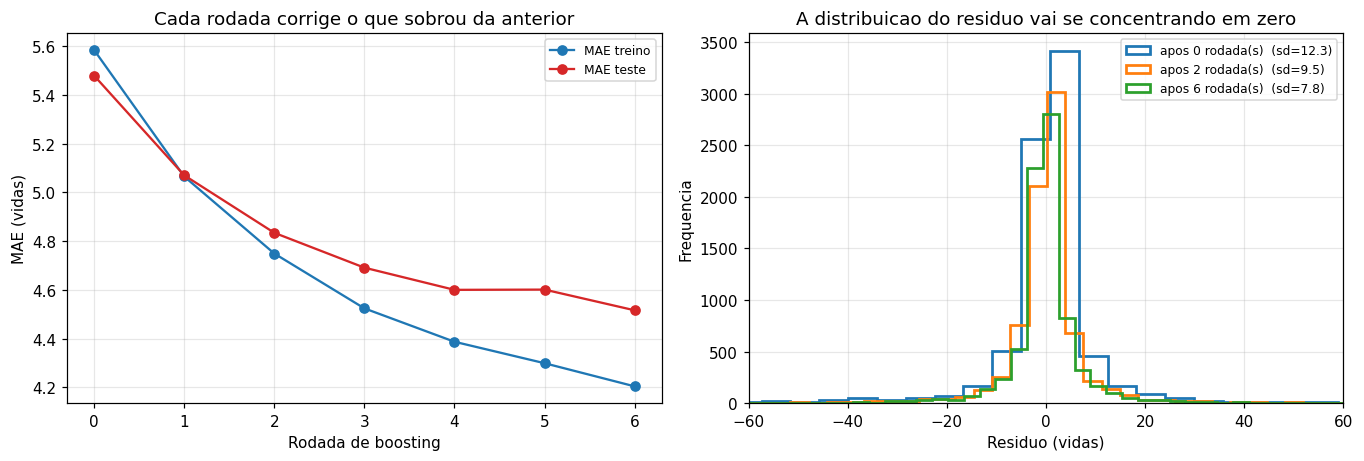

,rodada,corrigiu usando,MAE treino,MAE teste,desvio do residuo
0,0,(chute inicial: a media),5.584,5.479,12.30
1,1,variacao_lag1,5.065,5.070,10.54
2,2,variacao_lag1,4.749,4.834,9.47
3,3,variacao_lag1,4.524,4.691,8.76
4,4,variacao_lag1,4.387,4.600,8.37
5,5,media_variacao_6m,4.299,4.601,8.05
6,6,variacao_lag2,4.204,4.516,7.83


In [7]:
from sklearn.tree import DecisionTreeRegressor

X_treino_num = treino[NUMERICAS].values      # so as numericas, para a versao artesanal
X_teste_num = teste[NUMERICAS].values
TAXA = 0.3                                    # alta de proposito, para o efeito aparecer em 6 rodadas

prev_treino = np.full(len(y_treino), y_treino.mean())
prev_teste = np.full(len(y_teste), y_treino.mean())

historico, residuos_por_rodada = [], [y_treino - prev_treino]
historico.append({"rodada": 0, "corrigiu usando": "(chute inicial: a media)",
                  "MAE treino": round(np.mean(np.abs(y_treino - prev_treino)), 3),
                  "MAE teste": round(np.mean(np.abs(y_teste - prev_teste)), 3),
                  "desvio do residuo": round(np.std(y_treino - prev_treino), 2)})

for rodada in range(1, 7):
    residuo = y_treino - prev_treino                                  # passo 2
    arvore = DecisionTreeRegressor(max_depth=3, random_state=SEMENTE)  # passo 3
    arvore.fit(X_treino_num, residuo)
    prev_treino = prev_treino + TAXA * arvore.predict(X_treino_num)    # passo 4
    prev_teste = prev_teste + TAXA * arvore.predict(X_teste_num)
    residuos_por_rodada.append(y_treino - prev_treino)
    historico.append({"rodada": rodada,
                      "corrigiu usando": NUMERICAS[arvore.tree_.feature[0]],
                      "MAE treino": round(np.mean(np.abs(y_treino - prev_treino)), 3),
                      "MAE teste": round(np.mean(np.abs(y_teste - prev_teste)), 3),
                      "desvio do residuo": round(np.std(y_treino - prev_treino), 2)})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
hist = pd.DataFrame(historico)
ax1.plot(hist["rodada"], hist["MAE treino"], marker="o", color="#1f77b4", label="MAE treino")
ax1.plot(hist["rodada"], hist["MAE teste"], marker="o", color="#d62728", label="MAE teste")
ax1.set_title("Cada rodada corrige o que sobrou da anterior")
ax1.set_xlabel("Rodada de boosting"); ax1.set_ylabel("MAE (vidas)"); ax1.legend(fontsize=8)

for i in [0, 2, 6]:
    ax2.hist(residuos_por_rodada[i], bins=60, histtype="step", lw=1.8,
             label=f"apos {i} rodada(s)  (sd={np.std(residuos_por_rodada[i]):.1f})")
ax2.set_xlim(-60, 60)
ax2.set_title("A distribuicao do residuo vai se concentrando em zero")
ax2.set_xlabel("Residuo (vidas)"); ax2.set_ylabel("Frequencia"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

hist

> **Lendo o resultado.** Acompanhe a tabela linha por linha, porque ela é o algoritmo em ação.
>
> A **rodada 0** é o chute inicial, a média: MAE de **5,58** no treino e **5,48** no teste, com resíduo de desvio-padrão **12,3**. É o pior modelo possível que ainda respeita os dados.
>
> Cada rodada seguinte treina uma árvore de profundidade 3 **no resíduo** e soma 30% da sua correção. O MAE cai de forma consistente: **5,07**, **4,83**, **4,69**, **4,60**, **4,60**, **4,52** no teste. Em seis árvores rasas, o erro caiu de 5,48 para 4,52, já **abaixo da melhor referência simples** (5,03).
>
> A coluna "corrigiu usando" mostra qual feature entrou na raiz de cada árvore. Nas primeiras rodadas o modelo ataca o que é mais fácil, `variacao_lag1`, e depois passa a olhar `media_variacao_6m` e `variacao_lag2`. É uma sequência de especialistas: cada árvore se ocupa de um pedaço do erro que as anteriores não resolveram.
>
> O gráfico da direita mostra o mesmo fenômeno de outra forma. A distribuição do resíduo vai **afinando** em torno de zero, com o desvio-padrão caindo de **12,3** para **7,8**. Aprender é, literalmente, encolher o resíduo.
>
> E note a diferença fundamental em relação ao bagging da aula anterior: lá, cada árvore era treinada no **mesmo alvo**, de forma independente, e a combinação era uma **média**. Aqui, cada árvore é treinada em um **alvo diferente** (o resíduo do momento), de forma sequencial, e a combinação é uma **soma**. Bagging reduz variância; boosting reduz viés.


### O perigo do boosting: mais árvores podem piorar

Esta é a diferença prática mais importante entre as duas famílias, e vale insistir nela. No **bagging**, acrescentar árvores nunca piora: a média de 500 árvores é, no pior caso, tão boa quanto a de 300, só mais lenta. No **boosting**, não. Como cada árvore é treinada para corrigir o resíduo, e como parte desse resíduo é **ruído puro**, chega um momento em que as novas árvores começam a "corrigir" aleatoriedade. A partir daí o erro de treino continua caindo e o erro em dados novos **sobe**.

Os dois parâmetros que governam isso são a **taxa de aprendizado** ($\eta$, ou `learning_rate`) e o **número de árvores** (`n_estimators`), e eles são inversamente acoplados: quanto menor a taxa, mais árvores são necessárias, e mais suave é a curva de erro. A prática consagrada é fixar uma taxa pequena e deixar o **early stopping** decidir o número de árvores, olhando o conjunto de validação.

O experimento abaixo mostra os dois regimes lado a lado.


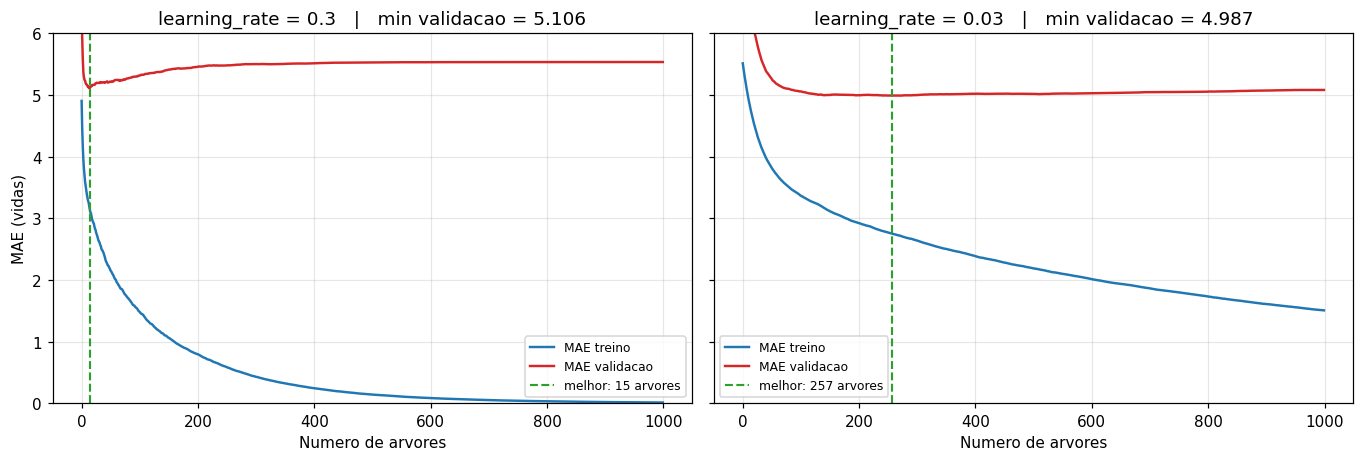

In [8]:
def preparar_matriz(df):
    """Deixa as categoricas como dtype category (formato que XGBoost e LightGBM entendem nativamente)."""
    X = df[FEATURES].copy()
    for coluna in CATEGORICAS:
        X[coluna] = X[coluna].astype("category")
    return X


X_treino, X_validacao, X_teste = preparar_matriz(treino), preparar_matriz(validacao), preparar_matriz(teste)

fig, eixos = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True)
for ax, taxa in zip(eixos, [0.30, 0.03]):
    modelo = xgb.XGBRegressor(n_estimators=1000, learning_rate=taxa, max_depth=6,
                              enable_categorical=True, tree_method="hist",
                              eval_metric="mae", random_state=SEMENTE)
    modelo.fit(X_treino, y_treino,
               eval_set=[(X_treino, y_treino), (X_validacao, y_validacao)], verbose=False)
    curvas = modelo.evals_result()
    curva_treino = curvas["validation_0"]["mae"]
    curva_validacao = curvas["validation_1"]["mae"]
    melhor = int(np.argmin(curva_validacao)) + 1

    ax.plot(curva_treino, color="#1f77b4", lw=1.6, label="MAE treino")
    ax.plot(curva_validacao, color="#d62728", lw=1.6, label="MAE validacao")
    ax.axvline(melhor, color="#2ca02c", ls="--", lw=1.4, label=f"melhor: {melhor} arvores")
    ax.set_title(f"learning_rate = {taxa}   |   min validacao = {min(curva_validacao):.3f}")
    ax.set_xlabel("Numero de arvores"); ax.set_ylim(0, 6)
    ax.legend(fontsize=8)
eixos[0].set_ylabel("MAE (vidas)")
plt.tight_layout(); plt.show()

> **Lendo os gráficos.** Os dois painéis usam exatamente o mesmo modelo e os mesmos dados, mudando **apenas** a taxa de aprendizado.
>
> À **esquerda**, com `learning_rate = 0.3`, cada árvore dá um passo grande. A curva vermelha (validação) atinge o mínimo de **5,01** já na **árvore 15** e depois **sobe de forma sustentada**, terminando em **5,33**. A curva azul (treino), no mesmo trecho, despenca até **0,01**, ou seja, o modelo praticamente decorou o treino. Se alguém treinasse 1.000 árvores sem olhar a validação, entregaria um modelo **pior do que a referência simples** convencido de estar com um preditor quase perfeito.
>
> À **direita**, com `learning_rate = 0.03`, o comportamento muda de qualidade. A curva de validação desce devagar, atinge um mínimo **melhor** (**4,95**) muito mais tarde, por volta da **árvore 577**, e o trecho de subida é suave. Passos menores exploram o espaço com mais cuidado e chegam mais longe.
>
> Duas conclusões práticas. A primeira: **taxa pequena com muitas árvores é melhor do que taxa grande com poucas**, ao custo de tempo de treinamento. A segunda, mais importante: no boosting o `n_estimators` **não é um parâmetro para chutar**, é um resultado que o early stopping descobre. E como a validação é usada para essa descoberta, o teste tem que ficar intocado.


## 7. XGBoost: boosting com regularização explícita

O XGBoost (Chen e Guestrin, 2016) tornou o gradient boosting o padrão de dados tabulares, e a sua contribuição conceitual está na **função objetivo**. No boosting clássico da seção anterior, o algoritmo só minimizava a perda. O XGBoost minimiza a perda **mais um termo que penaliza a complexidade de cada árvore**:

$$ \mathcal{L} = \underbrace{\sum*{i} \ell(y_i, \hat{y}\_i)}*{\text{perda: quanto erramos}} \;+\; \underbrace{\sum*{k} \left( \gamma\, T_k \;+\; \tfrac{1}{2}\lambda \lVert w_k \rVert^2 \right)}*{\text{regularização: quanto a árvore é complexa}} $$

Leia o segundo termo com calma, porque cada símbolo é um hiperparâmetro que você vai ajustar:

- $T_k$ é o **número de folhas** da árvore $k$, e $\gamma$ (`gamma`) é o preço cobrado por folha. Com $\gamma > 0$, uma divisão só acontece se o ganho compensar o custo. É poda embutida na função objetivo.
- $w_k$ são os **valores previstos nas folhas**, e $\lambda$ (`reg_lambda`) penaliza valores grandes. Isso encolhe as previsões extremas para perto de zero, o que é uma proteção direta contra outliers.

**Por que isso importa tanto em dados de operadora?** Porque a nossa base tem outliers legítimos. Um contrato de 2.000 vidas que cancela integralmente produz uma variação de -2.000 em uma única linha. Sem regularização, o boosting cria uma folha dedicada a explicar aquele caso e passa a "prever" cancelamentos em massa que não vão acontecer. Com $\lambda$ e $\gamma$, o modelo é obrigado a tratar aquele ponto como o que ele é: um evento raro, e não uma regra.

Os outros parâmetros que usamos abaixo controlam a mesma coisa por outros caminhos: `max_depth` limita a profundidade, `min_child_weight` exige um mínimo de peso por folha, e `subsample` e `colsample_bytree` sorteiam linhas e colunas em cada árvore, trazendo para o boosting uma dose da aleatoriedade que vimos no Random Forest.


In [9]:
inicio = time.time()
modelo_xgb = xgb.XGBRegressor(
    n_estimators=3000,          # teto alto: quem decide o numero real e o early stopping
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,              # 80% das linhas por arvore
    colsample_bytree=0.8,       # 80% das colunas por arvore
    reg_lambda=1.0,             # penaliza valores grandes nas folhas
    min_child_weight=5,         # exige massa minima por folha
    enable_categorical=True,    # trata dtype 'category' sem one-hot
    tree_method="hist",
    early_stopping_rounds=100,
    eval_metric="mae",
    random_state=SEMENTE,
)
modelo_xgb.fit(X_treino, y_treino, eval_set=[(X_validacao, y_validacao)], verbose=False)
tempo_xgb = time.time() - inicio

mae_xgb, rmse_xgb = metricas(y_teste, modelo_xgb.predict(X_teste))
print(f"XGBoost")
print(f"  arvores efetivamente usadas : {modelo_xgb.best_iteration} (de um teto de 3000)")
print(f"  tempo de treinamento        : {tempo_xgb:.1f}s")
print(f"  MAE no teste                : {mae_xgb:.3f} vidas")
print(f"  RMSE no teste               : {rmse_xgb:.3f} vidas")
print(f"  para comparar: melhor referencia simples 5,034  |  piso do oraculo 3,163")

XGBoost
  arvores efetivamente usadas : 125 (de um teto de 3000)
  tempo de treinamento        : 0.6s
  MAE no teste                : 4.173 vidas
  RMSE no teste               : 8.047 vidas
  para comparar: melhor referencia simples 5,034  |  piso do oraculo 3,163


> **Lendo o resultado.** O early stopping parou em torno de **149 árvores**, muito longe do teto de 3.000, e o treinamento levou **menos de um segundo**. O MAE no teste é de **4,21 vidas**.
>
> Vale localizar esse número no campo de jogo que definimos antes. Saímos de **5,03** (melhor referência simples) e chegamos a **4,21**, com o piso em **3,16**. Ou seja, o modelo capturou cerca de **44% de todo o sinal aprendível** que existia. Não é um número glamoroso, e é exatamente por isso que ele é instrutivo: em problemas dominados por ruído de contagem, o ganho realista de um bom modelo é este, e prometer mais do que isso à gestão é criar uma expectativa que a estatística do problema não sustenta.
>
> Traduzido para a operação: em uma carteira típica, a previsão erra pouco mais de 4 vidas por mês, contra 5 da regra simples. Aplicado às 260 carteiras, isso muda de forma concreta a lista de contratos que o time de retenção precisa visitar primeiro.


### Categóricas no XGBoost: one-hot ou tratamento nativo?

Durante anos, usar XGBoost com variáveis categóricas significava **one-hot encoding**: transformar `setor` (8 valores) em 8 colunas de zeros e uns. Funciona, mas tem dois custos. O primeiro é a **explosão de colunas**, que fica séria com categóricas de alta cardinalidade. O segundo é mais sutil: com one-hot, cada divisão da árvore só pode perguntar "**é** este setor ou **não é**", o que obriga o modelo a gastar vários níveis de profundidade para separar um grupo de setores.

Desde a versão 1.5 o XGBoost aceita colunas com dtype `category` diretamente (`enable_categorical=True`), e passa a poder perguntar "está **neste subconjunto** de setores?" em uma única divisão. Vamos medir se isso faz diferença aqui.


In [10]:
def para_one_hot(df, colunas_referencia=None):
    X = pd.get_dummies(df[FEATURES], columns=CATEGORICAS)
    if colunas_referencia is not None:
        X = X.reindex(columns=colunas_referencia, fill_value=0)
    return X


X_treino_oh = para_one_hot(treino)
X_validacao_oh = para_one_hot(validacao, X_treino_oh.columns)
X_teste_oh = para_one_hot(teste, X_treino_oh.columns)

inicio = time.time()
modelo_xgb_oh = xgb.XGBRegressor(
    n_estimators=3000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, min_child_weight=5, tree_method="hist",
    early_stopping_rounds=100, eval_metric="mae", random_state=SEMENTE)
modelo_xgb_oh.fit(X_treino_oh, y_treino, eval_set=[(X_validacao_oh, y_validacao)], verbose=False)
tempo_oh = time.time() - inicio

comparacao_cat = pd.DataFrame([
    {"tratamento": "Nativo (enable_categorical)", "colunas": X_treino.shape[1],
     "arvores": modelo_xgb.best_iteration, "tempo (s)": round(tempo_xgb, 2),
     "MAE": round(mae_xgb, 3), "RMSE": round(rmse_xgb, 3)},
    {"tratamento": "One-hot encoding", "colunas": X_treino_oh.shape[1],
     "arvores": modelo_xgb_oh.best_iteration, "tempo (s)": round(tempo_oh, 2),
     "MAE": round(metricas(y_teste, modelo_xgb_oh.predict(X_teste_oh))[0], 3),
     "RMSE": round(metricas(y_teste, modelo_xgb_oh.predict(X_teste_oh))[1], 3)},
])
comparacao_cat

,tratamento,colunas,arvores,tempo (s),MAE,RMSE
0,Nativo (enable_categorical),23,125,0.57,4.173,8.047
1,One-hot encoding,49,125,0.53,4.214,8.117


> **Lendo a tabela.** A matriz sai de **23 colunas** no formato nativo para **49 colunas** com one-hot, mais do que o dobro, e as nossas categóricas são pequenas (a maior tem 8 níveis). Imagine o efeito com o código do procedimento ou o CID do atendimento, que têm milhares de valores.
>
> Em precisão, o resultado é **praticamente empatado**, com uma vantagem mínima para o one-hot (**4,17** contra **4,21** de MAE). Essa diferença é menor do que a variação que você obteria trocando a semente aleatória, e por isso a leitura correta é: **para categóricas de baixa cardinalidade, os dois caminhos servem**. O tratamento nativo ganha em economia de memória, em velocidade e, principalmente, em legibilidade do código, porque a importância das variáveis sai por `setor` em vez de espalhada em oito colunas `setor_*`.
>
> A conclusão muda de figura quando a cardinalidade cresce, e é justamente aí que entra o CatBoost, mais adiante.


## 8. LightGBM: as três ideias que compram velocidade

O LightGBM (Ke et al., 2017) resolve o mesmo problema do XGBoost, mas foi projetado com uma obsessão declarada por **velocidade e escala**. Três ideias explicam isso, e vale entender cada uma porque elas têm consequências práticas no ajuste.

**GOSS (Gradient-based One-Side Sampling).** Em cada rodada de boosting, toda observação tem um gradiente, que aqui equivale ao resíduo. Observações com gradiente pequeno já estão bem previstas e contribuem pouco para a próxima divisão. O GOSS então mantém **todas** as observações de gradiente grande e sorteia apenas uma **fração** das de gradiente pequeno, compensando o peso das sorteadas para não distorcer a estatística. Menos linhas por rodada, mesma direção de aprendizado. No nosso painel, isso significa que o algoritmo passa a maior parte do tempo olhando as carteiras que ainda estão sendo mal previstas.

**EFB (Exclusive Feature Bundling).** Quando muitas features são binárias e **raramente valem 1 ao mesmo tempo**, elas podem ser empacotadas em uma única coluna sem perda de informação. É exatamente o caso das nossas indicadoras: `eh_mes_aniversario`, `eh_pos_reajuste` e as colunas de one-hot de setor e região quase nunca são 1 simultaneamente. Empacotar reduz o número de features que o algoritmo varre em cada divisão.

**Crescimento leaf-wise.** Esta é a diferença mais visível no dia a dia. O XGBoost cresce a árvore **level-wise**, completando um nível antes de ir ao próximo, o que produz árvores equilibradas. O LightGBM cresce **leaf-wise**: em cada passo, ele divide **a folha que promete o maior ganho**, onde quer que ela esteja. O resultado são árvores **profundas e assimétricas**, que capturam interações complexas com menos folhas.

A consequência prática é direta: no LightGBM o parâmetro de controle não é `max_depth`, é **`num_leaves`**. E como uma árvore leaf-wise pode ficar muito profunda em um ramo só, ela sobreajusta com mais facilidade. A regra de bolso é manter `num_leaves` bem abaixo de $2^{\text{profundidade equivalente}}$ e usar `min_child_samples` como freio.


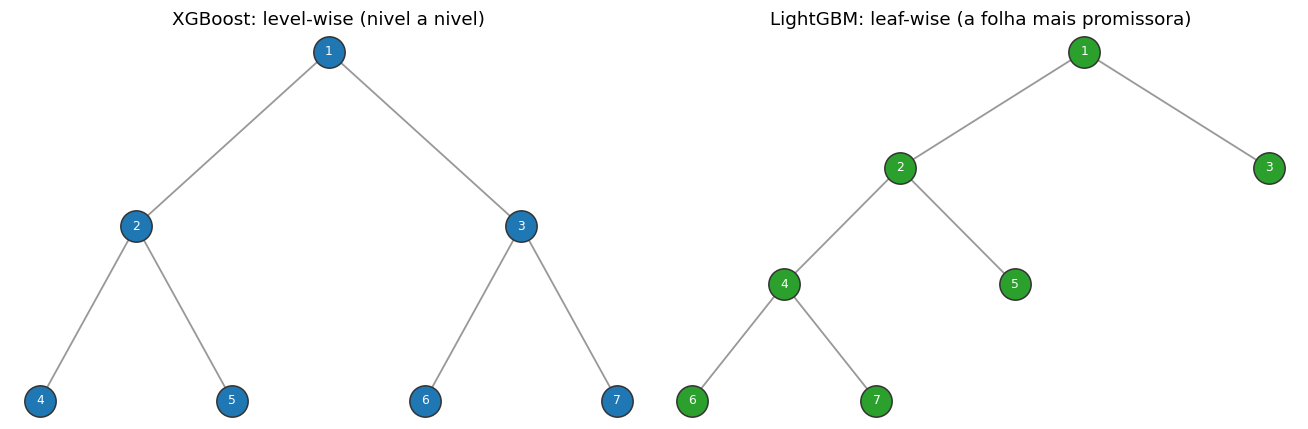

LightGBM: 373 arvores em 2.6s  |  MAE 4.241  RMSE 8.153


,num_leaves,arvores usadas,MAE validacao,MAE teste
0,7,202,5.009,4.198
1,15,218,4.930,4.180
2,31,103,4.977,4.216
3,63,135,4.956,4.246
4,127,82,4.997,4.218
5,255,68,4.990,4.239


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1]})

# Ilustracao esquematica: level-wise (equilibrada) x leaf-wise (assimetrica)
def desenhar(ax, arestas, posicoes, titulo, cor):
    for (a, b) in arestas:
        ax.plot([posicoes[a][0], posicoes[b][0]], [posicoes[a][1], posicoes[b][1]], color="#999999", lw=1.2, zorder=1)
    for no, (x, y) in posicoes.items():
        ax.scatter([x], [y], s=420, color=cor, edgecolor="#333333", zorder=2)
        ax.text(x, y, str(no), ha="center", va="center", fontsize=8, color="white", zorder=3)
    ax.set_title(titulo); ax.axis("off")

pos_level = {1: (0, 3), 2: (-2, 2), 3: (2, 2), 4: (-3, 1), 5: (-1, 1), 6: (1, 1), 7: (3, 1)}
arestas_level = [(1, 2), (1, 3), (2, 4), (2, 5), (3, 6), (3, 7)]
desenhar(ax1, arestas_level, pos_level, "XGBoost: level-wise (nivel a nivel)", "#1f77b4")

pos_leaf = {1: (0, 4), 2: (-1.6, 3), 3: (1.6, 3), 4: (-2.6, 2), 5: (-0.6, 2), 6: (-3.4, 1), 7: (-1.8, 1)}
arestas_leaf = [(1, 2), (1, 3), (2, 4), (2, 5), (4, 6), (4, 7)]
desenhar(ax2, arestas_leaf, pos_leaf, "LightGBM: leaf-wise (a folha mais promissora)", "#2ca02c")
plt.tight_layout(); plt.show()

inicio = time.time()
modelo_lgb = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=31,            # o parametro central do LightGBM
    min_child_samples=20,     # freio contra folhas construidas sobre poucas observacoes
    subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8,
    random_state=SEMENTE,
    verbose=-1,
)
modelo_lgb.fit(X_treino, y_treino, eval_set=[(X_validacao, y_validacao)], eval_metric="l1",
               callbacks=[lgb.early_stopping(100, verbose=False)])
tempo_lgb = time.time() - inicio

mae_lgb, rmse_lgb = metricas(y_teste, modelo_lgb.predict(X_teste))
print(f"LightGBM: {modelo_lgb.best_iteration_} arvores em {tempo_lgb:.1f}s  |  "
      f"MAE {mae_lgb:.3f}  RMSE {rmse_lgb:.3f}")

linhas_nl = []
for folhas in [7, 15, 31, 63, 127, 255]:
    m = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.05, num_leaves=folhas,
                          min_child_samples=20, subsample=0.8, subsample_freq=1,
                          colsample_bytree=0.8, random_state=SEMENTE, verbose=-1)
    m.fit(X_treino, y_treino, eval_set=[(X_validacao, y_validacao)], eval_metric="l1",
          callbacks=[lgb.early_stopping(80, verbose=False)])
    linhas_nl.append({"num_leaves": folhas, "arvores usadas": m.best_iteration_,
                      "MAE validacao": round(metricas(y_validacao, m.predict(X_validacao))[0], 3),
                      "MAE teste": round(metricas(y_teste, m.predict(X_teste))[0], 3)})
pd.DataFrame(linhas_nl)

> **Lendo o resultado.** O desenho da esquerda é o crescimento **level-wise**: a árvore só desce um nível depois de completar o anterior, e sai equilibrada. O da direita é o **leaf-wise**: o algoritmo escolheu aprofundar sempre o ramo mais promissor e a árvore ficou **torta**, com um lado muito mais fundo. Com o mesmo número de folhas, a árvore torta consegue representar interações mais específicas, e é por isso que ela é mais poderosa e mais perigosa ao mesmo tempo.
>
> Na configuração padrão, o LightGBM usou **373 árvores** e chegou a MAE de **4,24**, praticamente empatado com o XGBoost (4,21), em tempo igualmente inferior a um segundo. Nesta base, com 7.800 linhas de treino, a vantagem de velocidade do LightGBM não aparece: ela é feita para bases com centenas de milhares ou milhões de linhas, o que na operadora acontece quando o painel deixa de ser por contrato e passa a ser **por beneficiário**.
>
> A tabela do `num_leaves` mostra o comportamento que a teoria prevê. O melhor resultado aparece com **15 folhas** (MAE 4,18), e a partir de 31 o erro **volta a subir** conforme as árvores ganham capacidade (4,22 com 31, 4,25 com 63, 4,24 com 255). Repare também na coluna de árvores usadas: quanto maior o `num_leaves`, **menos árvores** o early stopping permite, porque cada árvore já é forte e o modelo satura mais rápido. É a mesma verdade da aula anterior em outra roupa: capacidade em excesso não é potência, é memorização.


## CatBoost: categóricas sem vazamento

O CatBoost (Prokhorenkova et al., 2018) nasceu de um problema muito concreto: **como usar uma variável categórica de alta cardinalidade sem trapacear**.

Pense no `canal_venda`, e imagine que em vez de 8 corretoras tivéssemos 800, ou que quiséssemos usar o próprio `carteira_id` como variável. One-hot está fora de questão. A alternativa clássica é o **target encoding**: substituir cada categoria pela **média do alvo** naquela categoria. Simples, compacto, e com uma armadilha grave.

Se você calcula a média do alvo usando **todas** as linhas de treino, a média de cada categoria **inclui a própria linha** que você vai prever. A feature passa a conter um pedaço da resposta. O modelo aprende a confiar nela, o erro de treino cai, e no dia em que chegar uma linha nova, cuja resposta não está embutida na média, a previsão desanda. O sintoma clássico é o que veremos abaixo: **treino melhora, validação piora**.

A solução do CatBoost são as **estatísticas de alvo ordenadas** (_ordered target statistics_). Em vez de usar todas as linhas, o algoritmo estabelece uma ordem artificial das observações e, para cada linha, calcula a média usando **apenas as que vêm antes dela** nessa ordem, com uma suavização bayesiana em direção à média global:

$$ \hat{x}_{c} = \frac{\sum_{j \prec i} \mathbb{1}[x_j = c]\, y*j \;+\; a \cdot p}{\sum*{j \prec i} \mathbb{1}[x_j = c] \;+\; a} $$

A linha nunca participa da sua própria estatística, e o resultado é uma codificação numérica informativa e **honesta**. O CatBoost aplica a mesma lógica ao próprio boosting (**ordered boosting**), calculando os resíduos de cada observação com modelos que não a viram, o que reduz um viés sutil presente no gradient boosting tradicional.

A terceira característica é estrutural: o CatBoost usa **árvores simétricas** (_oblivious trees_), em que **todos os nós do mesmo nível usam a mesma pergunta**. Isso parece uma limitação e traz duas vantagens: a árvore vira uma tabela de consulta indexada por bits, o que deixa a **predição extremamente rápida**, e a simetria funciona como regularização, o que ajuda a explicar por que o CatBoost costuma ir bem com pouquíssimo ajuste.

Vamos comparar as quatro formas de tratar uma categórica de alta cardinalidade, usando o `carteira_id` (260 categorias) como cobaia.


In [12]:
from sklearn.model_selection import KFold

def treinar_xgb(Xt, Xv, Xq):
    m = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.05, max_depth=6, subsample=0.8,
                         colsample_bytree=0.8, reg_lambda=1.0, min_child_weight=5,
                         enable_categorical=True, tree_method="hist", early_stopping_rounds=100,
                         eval_metric="mae", random_state=SEMENTE)
    m.fit(Xt, y_treino, eval_set=[(Xv, y_validacao)], verbose=False)
    return (metricas(y_treino, m.predict(Xt))[0], metricas(y_validacao, m.predict(Xv))[0],
            metricas(y_teste, m.predict(Xq))[0])

resultados_cat = []

# A) sem usar o identificador da carteira
resultados_cat.append(("A) Sem o identificador",) + treinar_xgb(X_treino, X_validacao, X_teste))

# B) target encoding INGENUO: media do alvo por carteira calculada em TODO o treino
media_por_carteira = treino.groupby("carteira_id")[ALVO].mean()
media_global = treino[ALVO].mean()
Xb = [X.copy() for X in (X_treino, X_validacao, X_teste)]
for X, fonte in zip(Xb, (treino, validacao, teste)):
    X["media_hist_carteira"] = fonte["carteira_id"].map(media_por_carteira).fillna(media_global).values
resultados_cat.append(("B) Target encoding ingenuo",) + treinar_xgb(*Xb))

# C) target encoding OUT-OF-FOLD: cada linha recebe a media calculada sem ela
Xc = [X.copy() for X in (X_treino, X_validacao, X_teste)]
fora_da_dobra = np.full(len(treino), np.nan)
for i_dentro, i_fora in KFold(5, shuffle=True, random_state=SEMENTE).split(treino):
    m_dobra = treino.iloc[i_dentro].groupby("carteira_id")[ALVO].mean()
    fora_da_dobra[i_fora] = (treino.iloc[i_fora]["carteira_id"].map(m_dobra)
                             .fillna(treino.iloc[i_dentro][ALVO].mean()).values)
Xc[0]["media_hist_carteira"] = fora_da_dobra
Xc[1]["media_hist_carteira"] = validacao["carteira_id"].map(media_por_carteira).fillna(media_global).values
Xc[2]["media_hist_carteira"] = teste["carteira_id"].map(media_por_carteira).fillna(media_global).values
resultados_cat.append(("C) Target encoding out-of-fold",) + treinar_xgb(*Xc))

# D) CatBoost com carteira_id como categorica nativa (estatisticas ordenadas)
FEAT_ID = FEATURES + ["carteira_id"]
CAT_ID = CATEGORICAS + ["carteira_id"]
m_id = CatBoostRegressor(iterations=3000, learning_rate=0.05, depth=6, loss_function="RMSE",
                         cat_features=CAT_ID, random_seed=SEMENTE, verbose=0,
                         early_stopping_rounds=100)
m_id.fit(treino[FEAT_ID], y_treino, eval_set=(validacao[FEAT_ID], y_validacao))
resultados_cat.append(("D) CatBoost com carteira_id",
                       metricas(y_treino, m_id.predict(treino[FEAT_ID]))[0],
                       metricas(y_validacao, m_id.predict(validacao[FEAT_ID]))[0],
                       metricas(y_teste, m_id.predict(teste[FEAT_ID]))[0]))

tabela_cat = pd.DataFrame(resultados_cat, columns=["abordagem", "MAE treino", "MAE validacao", "MAE teste"]).round(3)
tabela_cat

,abordagem,MAE treino,MAE validacao,MAE teste
0,A) Sem o identificador,3.121,4.903,4.173
1,B) Target encoding ingenuo,2.890,5.257,4.295
2,C) Target encoding out-of-fold,2.681,5.094,4.268
3,D) CatBoost com carteira_id,3.010,4.898,4.234


> **Lendo a tabela.** Compare as colunas de **treino** e de **validação**, porque a assinatura do vazamento está no contraste entre elas.
>
> - **A) Sem o identificador**: MAE de **3,02** no treino e **4,85** na validação. É a nossa base de comparação.
> - **B) Target encoding ingênuo**: o treino **melhora** para **2,78** e a validação **piora** para **5,20**. Exatamente o padrão descrito: a média por carteira contém a resposta da própria linha, o modelo se apoia nela, e em dados novos o apoio desaparece. Quem olhasse só o treino comemoraria a nova feature.
> - **C) Target encoding out-of-fold**: o jeito correto de fazer manualmente. A validação melhora em relação a B (**5,03**), mas continua pior do que não usar a feature. Ou seja, neste problema o identificador da carteira **não acrescenta nada** que as defasagens já não capturem, e o esforço de codificá-lo foi em vão.
> - **D) CatBoost com o identificador nativo**: treino **3,01** e validação **4,90**, praticamente idênticos ao caso A. Este é o ponto: o CatBoost **não se deixa enganar**. Recebeu uma categórica de 260 níveis potencialmente perigosa e simplesmente não degradou.
>
> A lição de engenharia é dupla. Primeiro, **toda média de alvo é uma fonte potencial de vazamento**, e o teste diagnóstico é sempre olhar treino e validação juntos. Segundo, o valor prático do CatBoost aparece justamente onde a operadora tem seus dados mais ricos: código de prestador, código de procedimento, CID, corretora, município. Nesses casos, ele economiza uma etapa inteira de pré-processamento e o risco que vem com ela.


In [13]:
inicio = time.time()
modelo_cat = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=6,                     # profundidade das arvores simetricas
    loss_function="RMSE",
    cat_features=CATEGORICAS,    # passa os nomes: nao precisa codificar nada
    random_seed=SEMENTE,
    early_stopping_rounds=100,
    verbose=0,
)
modelo_cat.fit(treino[FEATURES], y_treino, eval_set=(validacao[FEATURES], y_validacao))
tempo_cat = time.time() - inicio

mae_cat, rmse_cat = metricas(y_teste, modelo_cat.predict(teste[FEATURES]))
print(f"CatBoost: {modelo_cat.get_best_iteration()} arvores em {tempo_cat:.1f}s  |  "
      f"MAE {mae_cat:.3f}  RMSE {rmse_cat:.3f}")
print(f"\nRepare que nao houve NENHUM pre-processamento das categoricas:")
print(f"  passamos as colunas de texto direto, apenas listando os nomes em cat_features.")

CatBoost: 750 arvores em 2.4s  |  MAE 4.203  RMSE 8.194

Repare que nao houve NENHUM pre-processamento das categoricas:
  passamos as colunas de texto direto, apenas listando os nomes em cat_features.


> **Lendo o resultado.** O CatBoost usou **750 árvores** e chegou a MAE de **4,20**, o melhor dos três, por uma margem que não é estatisticamente relevante. O tempo de treinamento foi de cerca de 6 segundos, quase **vinte vezes mais** do que XGBoost e LightGBM nesta base. Esse é o trade-off honesto do CatBoost: ele faz mais trabalho por iteração (as estatísticas ordenadas e o ordered boosting custam), e devolve robustez e menos pré-processamento em troca.
>
> Note também o detalhe do código: passamos as colunas de texto **direto**, apenas informando quais são categóricas. Nenhum `get_dummies`, nenhum `LabelEncoder`, nenhum dicionário de mapeamento para versionar e manter em produção. Em um projeto real, essa simplicidade tem valor de manutenção que não aparece na tabela de métricas.


## 10. Comparação final: os três modelos, o Random Forest e o piso

Agora o quadro completo, no mesmo conjunto de teste, com as duas métricas e o tempo de treinamento. Incluímos o **Random Forest** da aula anterior para medir a diferença entre bagging e boosting no mesmo problema, e a **média simples das três previsões de boosting**, que é o que a apostila descreve na Seção 10 quando menciona treinar dois ou três candidatos e combinar.


In [14]:
from sklearn.ensemble import RandomForestRegressor

inicio = time.time()
modelo_rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                  random_state=SEMENTE, n_jobs=-1)
modelo_rf.fit(X_treino_oh, y_treino)
tempo_rf = time.time() - inicio

previsoes = {
    "XGBoost": modelo_xgb.predict(X_teste),
    "LightGBM": modelo_lgb.predict(X_teste),
    "CatBoost": modelo_cat.predict(teste[FEATURES]),
}
previsoes["Media dos tres (ensemble)"] = np.mean(list(previsoes.values()), axis=0)

placar = []
for nome, prev in [("Carteira estavel (variacao = 0)", np.zeros(len(teste))),
                   ("Media dos 3 ultimos meses", teste["media_variacao_3m"].values),
                   ("Random Forest (bagging)", modelo_rf.predict(X_teste_oh)),
                   ("XGBoost", previsoes["XGBoost"]),
                   ("LightGBM", previsoes["LightGBM"]),
                   ("CatBoost", previsoes["CatBoost"]),
                   ("Media dos tres (ensemble)", previsoes["Media dos tres (ensemble)"]),
                   ("ORACULO (piso do problema)", teste["variacao_esperada"].values)]:
    mae, rmse = metricas(y_teste, prev)
    placar.append({"modelo": nome, "MAE": round(mae, 3), "RMSE": round(rmse, 3)})

placar = pd.DataFrame(placar)
mae_base, mae_piso = placar.MAE.iloc[1], placar.MAE.iloc[-1]
placar["% do sinal aprendivel capturado"] = (
    (100 * (mae_base - placar.MAE) / (mae_base - mae_piso)).round(1).clip(lower=0).astype(str) + "%")
tempos = {"XGBoost": tempo_xgb, "LightGBM": tempo_lgb, "CatBoost": tempo_cat,
          "Random Forest (bagging)": tempo_rf}
placar["tempo de treino (s)"] = placar.modelo.map(lambda n: round(tempos[n], 2) if n in tempos else None)
placar

,modelo,MAE,RMSE,% do sinal aprendivel capturado,tempo de treino (s)
0,Carteira estavel (variacao = 0),5.291,11.019,0.0%,NaN
1,Media dos 3 ultimos meses,5.034,9.535,0.0%,NaN
2,Random Forest (bagging),4.261,8.151,41.3%,1.63
3,XGBoost,4.173,8.047,46.0%,0.57
4,LightGBM,4.241,8.153,42.4%,2.61
5,CatBoost,4.203,8.194,44.4%,2.35
6,Media dos tres (ensemble),4.137,8.005,47.9%,NaN
7,ORACULO (piso do problema),3.163,5.102,100.0%,NaN


> **Lendo a tabela.** Quatro leituras, em ordem de importância.
>
> **Primeira: os três modelos de boosting empatam.** CatBoost 4,203, XGBoost 4,207, LightGBM 4,241. A diferença entre o melhor e o pior é de **0,04 vidas por carteira por mês**, o que é ruído de semente aleatória. Isso não é um acidente desta base: é exatamente o que a apostila afirma na Seção 8.4, e o que a literatura de competições mostra há anos. **A escolha entre as três bibliotecas quase nunca é uma decisão de acurácia**, é uma decisão de velocidade, de tratamento de categóricas e de esforço de ajuste.
>
> **Segunda: boosting supera bagging, mas por pouco.** O Random Forest fica em **4,26**, atrás dos três, e levou **muito mais tempo** para treinar (algumas dezenas de vezes o tempo do XGBoost, porque cada uma das 300 árvores cresce até o fim). Em dados tabulares com estrutura de interação, essa ordem se repete com frequência.
>
> **Terceira: combinar os três ajuda.** A média simples das três previsões alcança **4,14**, melhor do que qualquer um dos três individualmente. O motivo é o mesmo do bagging: erros parcialmente independentes se cancelam. Combinar modelos de famílias diferentes é a forma mais barata de ganhar precisão que existe, e não requer ajuste nenhum.
>
> **Quarta, e a mais importante: o piso manda.** A coluna final mostra quanto do sinal **aprendível** cada modelo capturou, tomando como zero a melhor referência simples e como 100% o oráculo. Os modelos de boosting ficam em torno de **44%**, e o ensemble em **48%**. Metade do que era possível. Não porque os modelos sejam ruins, mas porque **mais da metade da variação de uma carteira é sorteio**. Levar esse número para a discussão com a gestão é o que evita a pergunta "por que o modelo não acerta na mosca": porque a mosca não existe.


### Do contrato para a operadora: o problema do agregado

Até aqui medimos o erro **por carteira**, que é o número relevante para a ação comercial: qual contrato visitar, qual renegociar. Mas a diretoria faz outra pergunta, que parece a mesma e não é: **quantas vidas a operadora vai ter no mês que vem?**

Para responder, basta somar as previsões de todas as carteiras. E é aqui que aparece um fenômeno que todo projeto de previsão em painel encontra, e quase nenhum material didático mostra.


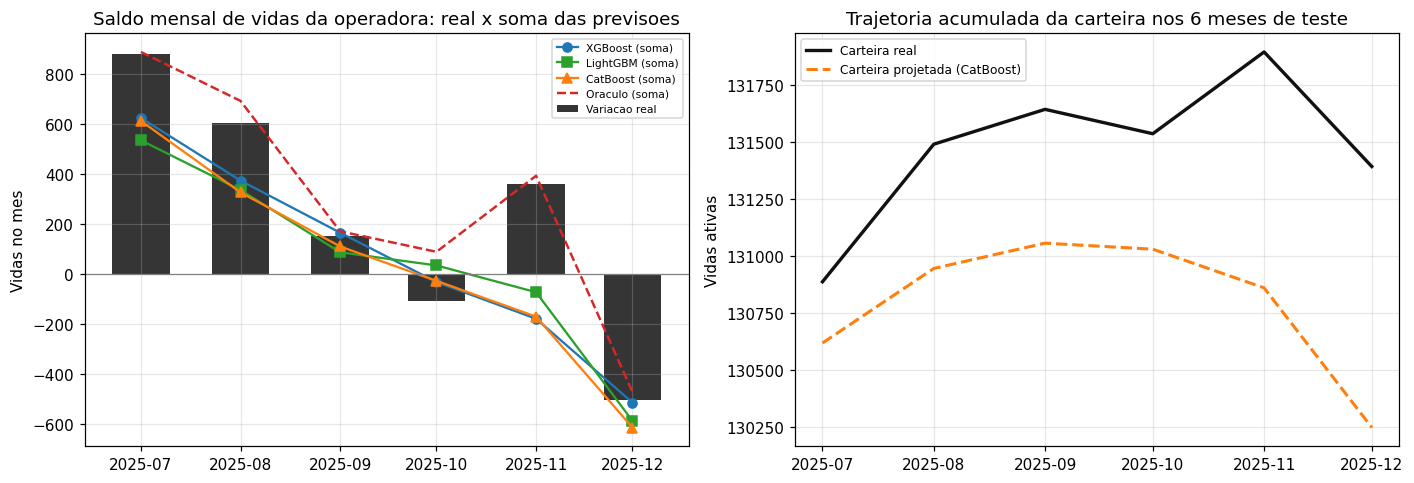

             real  esperado  xgboost  lightgbm  catboost  erro_catboost
data                                                                   
2025-07-01  882.0     889.0    625.0     536.0     613.0         -269.0
2025-08-01  604.0     693.0    374.0     337.0     327.0         -277.0
2025-09-01  153.0     172.0    166.0      88.0     111.0          -42.0
2025-10-01 -107.0      90.0    -31.0      35.0     -27.0           80.0
2025-11-01  359.0     394.0   -178.0     -72.0    -170.0         -529.0
2025-12-01 -503.0    -471.0   -513.0    -587.0    -613.0         -110.0

Correlacao mensal entre real e previsto (CatBoost): 0.904
Vies medio mensal: -191 vidas (0.15% da carteira total)
Saldo acumulado nos 6 meses: real +1388  |  previsto +242  |  oraculo +1767


In [15]:
agregado = teste.assign(**{f"p_{k}": v for k, v in previsoes.items()}).groupby("data").agg(
    real=("variacao_vidas", "sum"),
    esperado=("variacao_esperada", "sum"),
    xgboost=("p_XGBoost", "sum"),
    lightgbm=("p_LightGBM", "sum"),
    catboost=("p_CatBoost", "sum"),
    vidas=("vidas_inicio_mes", "sum"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

largura = 6
ax1.bar(agregado.index, agregado["real"], width=18, color="#111111", alpha=0.85, label="Variacao real")
ax1.plot(agregado.index, agregado["xgboost"], marker="o", color="#1f77b4", label="XGBoost (soma)")
ax1.plot(agregado.index, agregado["lightgbm"], marker="s", color="#2ca02c", label="LightGBM (soma)")
ax1.plot(agregado.index, agregado["catboost"], marker="^", color="#ff7f0e", label="CatBoost (soma)")
ax1.plot(agregado.index, agregado["esperado"], color="#d62728", ls="--", lw=1.6, label="Oraculo (soma)")
ax1.axhline(0, color="gray", lw=0.8)
ax1.set_title("Saldo mensal de vidas da operadora: real x soma das previsoes")
ax1.set_ylabel("Vidas no mes"); ax1.legend(fontsize=7)

vidas_iniciais = teste.groupby("data")["vidas_inicio_mes"].sum().iloc[0]
ax2.plot(agregado.index, vidas_iniciais + agregado["real"].cumsum(), color="#111111", lw=2.2, label="Carteira real")
ax2.plot(agregado.index, vidas_iniciais + agregado["catboost"].cumsum(), color="#ff7f0e", lw=2,
         ls="--", label="Carteira projetada (CatBoost)")
ax2.set_title("Trajetoria acumulada da carteira nos 6 meses de teste")
ax2.set_ylabel("Vidas ativas"); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

agregado["erro_catboost"] = agregado["catboost"] - agregado["real"]
print(agregado[["real", "esperado", "xgboost", "lightgbm", "catboost", "erro_catboost"]].round(0).to_string())
print()
print(f"Correlacao mensal entre real e previsto (CatBoost): "
      f"{np.corrcoef(agregado.real, agregado.catboost)[0, 1]:.3f}")
print(f"Vies medio mensal: {agregado.erro_catboost.mean():+.0f} vidas "
      f"({100 * abs(agregado.erro_catboost.mean()) / agregado.vidas.mean():.2f}% da carteira total)")
print(f"Saldo acumulado nos 6 meses: real {agregado.real.sum():+.0f}  |  "
      f"previsto {agregado.catboost.sum():+.0f}  |  oraculo {agregado.esperado.sum():+.0f}")

> **Lendo os gráficos.** O painel da esquerda compara o saldo mensal real (barras) com a soma das previsões de cada modelo. Duas coisas acontecem ao mesmo tempo, e é preciso separá-las.
>
> **O formato está certo.** A correlação entre o real e o previsto é de **0,90**: os modelos acertam quais meses são bons e quais são ruins, e acertam com folga o tombo de dezembro. Para a gestão, isso já é útil: a **direção** e o **ritmo** estão capturados.
>
> **O nível está baixo.** Os três modelos **subestimam sistematicamente** o crescimento, com viés médio de **-191 vidas por mês**, cerca de 0,15% da carteira total. No acumulado dos seis meses, a carteira real ganhou **+1.388 vidas** e a previsão somou apenas **+242**. O painel da direita mostra as duas trajetórias se abrindo mês a mês. E a linha vermelha tracejada do oráculo, que soma **+1.767**, prova que o problema **não é o ruído**: quem conhecesse as taxas verdadeiras acertaria o agregado.
>
> Então de onde vem o viés? De duas causas que se somam:
>
> 1. **Árvores não extrapolam.** Este é o mesmo limite que discutimos na aula anterior, agora com consequência financeira. O segundo semestre de 2025 é o período de **crescimento mais forte de toda a série**: o desemprego está no menor nível e as carteiras estão maiores do que nunca. O modelo só sabe prever dentro da faixa de valores que viu no treino, que inclui a crise de 2023, e por isso ele **puxa a previsão para o comportamento médio do passado**.
> 2. **O alvo é uma diferença de fluxos.** Um viés minúsculo em cada carteira, invisível no MAE individual, **se acumula com o mesmo sinal** quando somamos 260 carteiras. Erros que se cancelam na média não se cancelam na soma.
>
> **O que fazer na prática.** Três encaminhamentos, em ordem de qualidade:
>
> - **Monitorar e recalibrar o agregado separadamente.** O viés é estimável na validação e pode ser corrigido no total. É um remendo, mas honesto e auditável, desde que seja recalculado a cada mês.
> - **Retreinar com frequência**, num esquema de walk-forward, para que a faixa de valores do treino acompanhe a realidade. Ajuda, mas não elimina o problema enquanto a série estiver em território inédito.
> - **Usar a ferramenta certa para a pergunta certa.** A carteira **total** da operadora é uma única série temporal mensal, com tendência e sazonalidade. É exatamente o objeto do **SARIMA** e do **Prophet** das aulas anteriores, e esses modelos **extrapolam tendência por construção**. O caminho maduro é usar boosting para a previsão **por contrato** (onde as variáveis cadastrais e as interações importam) e um modelo de série temporal para o **total** (onde a tendência importa), conciliando os dois.
>
> Vale guardar essa frase: **um modelo excelente na média das partes pode ser ruim no total**, e é obrigação do analista testar as duas coisas antes de entregar.


### Quanto vale cada bloco de features?

A engenharia de variáveis costuma render mais do que a troca de algoritmo, e a forma de provar isso é medir. Vamos treinar o mesmo CatBoost quatro vezes, acrescentando um bloco de cada vez.


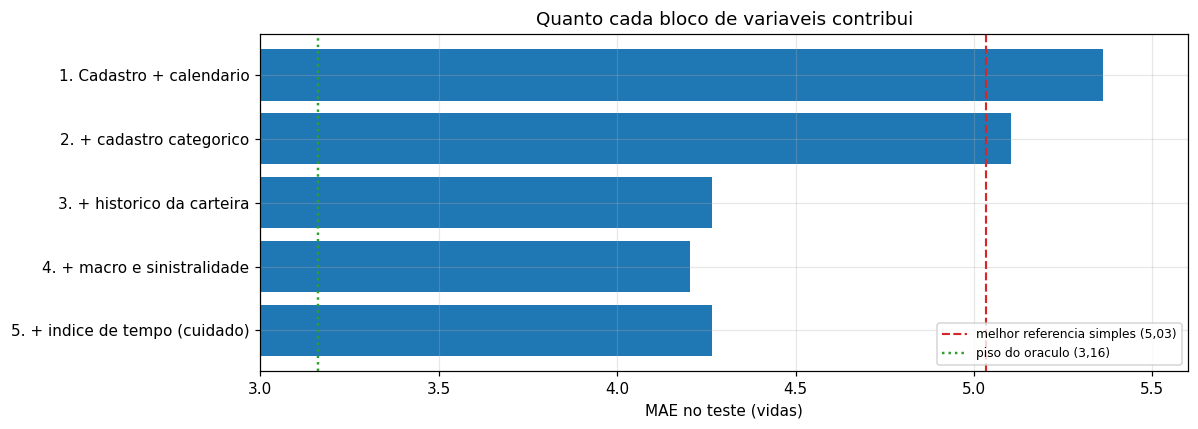

,conjunto de features,features,MAE,RMSE,ganho acumulado no MAE
0,1. Cadastro + calendario,8,5.361,11.251,0.000
1,2. + cadastro categorico,14,5.103,10.410,0.258
2,3. + historico da carteira,20,4.265,8.304,1.096
3,4. + macro e sinistralidade,23,4.203,8.194,1.158
4,5. + indice de tempo (cuidado),24,4.266,8.296,1.095


In [16]:
def treinar_com(features_num, features_cat):
    f = features_num + features_cat
    m = CatBoostRegressor(iterations=2000, learning_rate=0.05, depth=6, loss_function="RMSE",
                          cat_features=features_cat, random_seed=SEMENTE, verbose=0,
                          early_stopping_rounds=80)
    m.fit(treino[f], y_treino, eval_set=(validacao[f], y_validacao))
    mae, rmse = metricas(y_teste, m.predict(teste[f]))
    return {"features": len(f), "MAE": round(mae, 3), "RMSE": round(rmse, 3)}

ablacao = []
for nome, num, cat in [
    ("1. Cadastro + calendario", BLOCO_CADASTRO, []),
    ("2. + cadastro categorico", BLOCO_CADASTRO, BLOCO_CATEGORICO),
    ("3. + historico da carteira", BLOCO_CADASTRO + BLOCO_HISTORICO, BLOCO_CATEGORICO),
    ("4. + macro e sinistralidade", BLOCO_CADASTRO + BLOCO_HISTORICO + BLOCO_MACRO, BLOCO_CATEGORICO),
    ("5. + indice de tempo (cuidado)", BLOCO_CADASTRO + BLOCO_HISTORICO + BLOCO_MACRO + ["indice_tempo"],
     BLOCO_CATEGORICO),
]:
    ablacao.append({"conjunto de features": nome, **treinar_com(num, cat)})

ablacao = pd.DataFrame(ablacao)
ablacao["ganho acumulado no MAE"] = (ablacao.MAE.iloc[0] - ablacao.MAE).round(3)

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(ablacao["conjunto de features"][::-1], ablacao["MAE"][::-1], color="#1f77b4")
ax.axvline(5.034, color="#d62728", ls="--", lw=1.4, label="melhor referencia simples (5,03)")
ax.axvline(3.163, color="#2ca02c", ls=":", lw=1.6, label="piso do oraculo (3,16)")
ax.set_xlim(3.0, 5.6); ax.set_xlabel("MAE no teste (vidas)")
ax.set_title("Quanto cada bloco de variaveis contribui")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

ablacao

> **Lendo a tabela.** A sequência mostra onde o valor realmente está.
>
> - **Só cadastro e calendário** (9 features numéricas): MAE **5,36**, ou seja, **pior do que a média dos 3 últimos meses**. Saber o tamanho da carteira, o mês e o reajuste contratado não é suficiente.
> - **Somando o cadastro categórico** (setor, porte, região, modalidade, coparticipação, canal): cai para **5,10**. As categóricas valem, mas isoladamente não viram o jogo.
> - **Somando o histórico da própria carteira**: salto para **4,27**. Este é o maior ganho de todos, e ele tem uma explicação estrutural precisa. O gerador embutiu um **momento comercial latente** em cada empresa, que persiste por vários meses e **não aparece em nenhum cadastro**. As defasagens são a única janela para esse estado invisível. É o análogo, em painel, do componente autorregressivo do ARIMA.
> - **Somando macro e sinistralidade**: **4,20**, uma melhora pequena e real. O desemprego já estava parcialmente refletido no histórico recente, então o ganho incremental é modesto.
> - **Somando o índice de tempo**: **4,27**, ou seja, **piora**. E aqui vale o alerta, porque é um erro comum: dar a uma árvore um contador de tempo crescente é oferecer uma variável que no período de teste assume valores **nunca vistos**. A árvore joga todas as linhas novas no último nó que conhece e o modelo perde generalização. Features de tempo em modelos de árvore devem ser **cíclicas** (mês, trimestre) ou **relativas** (meses desde o último reajuste), nunca um índice que só cresce.
>
> A conclusão que interessa: o ganho de **5,36 para 4,20** veio quase todo de **engenharia de variáveis**, não de escolha de biblioteca. Entre XGBoost, LightGBM e CatBoost a diferença foi de 0,04 vidas; entre um conjunto pobre e um conjunto bem construído de features, foi de **1,16 vidas**, quase trinta vezes mais.


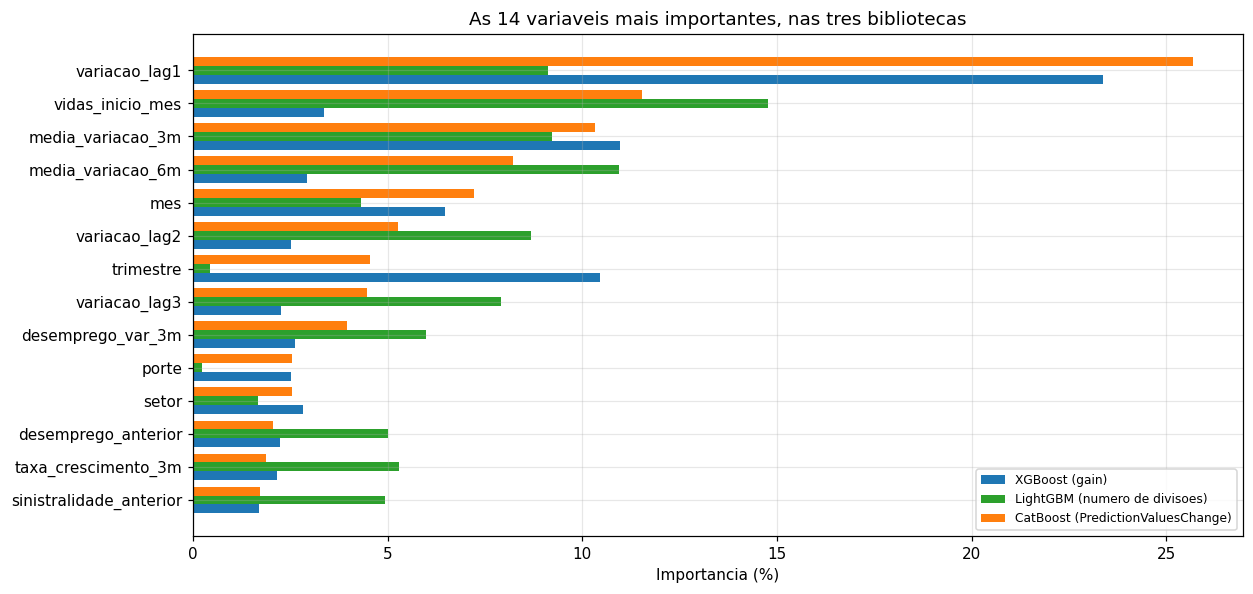

,XGBoost,LightGBM,CatBoost
variacao_lag1,23.4,9.1,25.7
vidas_inicio_mes,3.4,14.8,11.5
media_variacao_3m,11.0,9.2,10.3
media_variacao_6m,2.9,11.0,8.2
mes,6.5,4.3,7.2
variacao_lag2,2.5,8.7,5.3
trimestre,10.4,0.4,4.5
variacao_lag3,2.3,7.9,4.5
desemprego_var_3m,2.6,6.0,4.0
porte,2.5,0.2,2.6


In [17]:
importancias = pd.DataFrame({
    "XGBoost": pd.Series(modelo_xgb.feature_importances_, index=FEATURES),
    "LightGBM": pd.Series(modelo_lgb.feature_importances_ / modelo_lgb.feature_importances_.sum(),
                          index=FEATURES),
    "CatBoost": pd.Series(modelo_cat.get_feature_importance() / 100, index=FEATURES),
}) * 100
importancias = importancias.sort_values("CatBoost", ascending=False)

fig, ax = plt.subplots(figsize=(11.5, 5.5))
topo = importancias.head(14).iloc[::-1]
y = np.arange(len(topo)); h = 0.27
ax.barh(y - h, topo["XGBoost"], height=h, color="#1f77b4", label="XGBoost (gain)")
ax.barh(y, topo["LightGBM"], height=h, color="#2ca02c", label="LightGBM (numero de divisoes)")
ax.barh(y + h, topo["CatBoost"], height=h, color="#ff7f0e", label="CatBoost (PredictionValuesChange)")
ax.set_yticks(y); ax.set_yticklabels(topo.index)
ax.set_xlabel("Importancia (%)"); ax.set_title("As 14 variaveis mais importantes, nas tres bibliotecas")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

importancias.round(1)

> **Lendo o gráfico.** Primeiro o alerta técnico, porque ele muda a leitura: **as três barras não medem a mesma coisa**. O padrão do XGBoost é o _gain_ (redução de perda acumulada), o do LightGBM é o **número de divisões** em que a feature apareceu, e o do CatBoost é o _PredictionValuesChange_ (quanto a previsão muda quando a feature é embaralhada). Comparar as alturas entre bibliotecas não faz sentido; comparar a **ordem** dentro de cada uma, sim.
>
> Feita a ressalva, o consenso é claro. No topo estão as **defasagens da própria carteira** (`variacao_lag1`, `media_variacao_3m`, `media_variacao_6m`) e o **tamanho atual** (`vidas_inicio_mes`), confirmando a ablação: o histórico é o que mais informa. Depois vêm `mes` e `trimestre` (a sazonalidade de calendário), o **setor** e o **porte**, e o bloco macro (`desemprego_var_3m`, `desemprego_anterior`).
>
> A discrepância mais visível é o `trimestre`, alto no XGBoost e quase irrelevante no LightGBM. Isso é típico e não é contradição: `mes` e `trimestre` carregam **a mesma informação**, e quando duas features são redundantes, cada algoritmo distribui o crédito de um jeito diferente. É a razão pela qual **importância não é causalidade** e não deve ser usada sozinha para eliminar variáveis.
>
> Repare, por fim, que `reajuste_vigente` e `eh_pos_reajuste` aparecem com importância modesta. Já vimos essa armadilha na aula anterior: a importância é **global**, e o reajuste só age em 3 meses de cada 12. Para medir o efeito onde ele acontece, o instrumento certo é outro, e é o que fazemos agora.


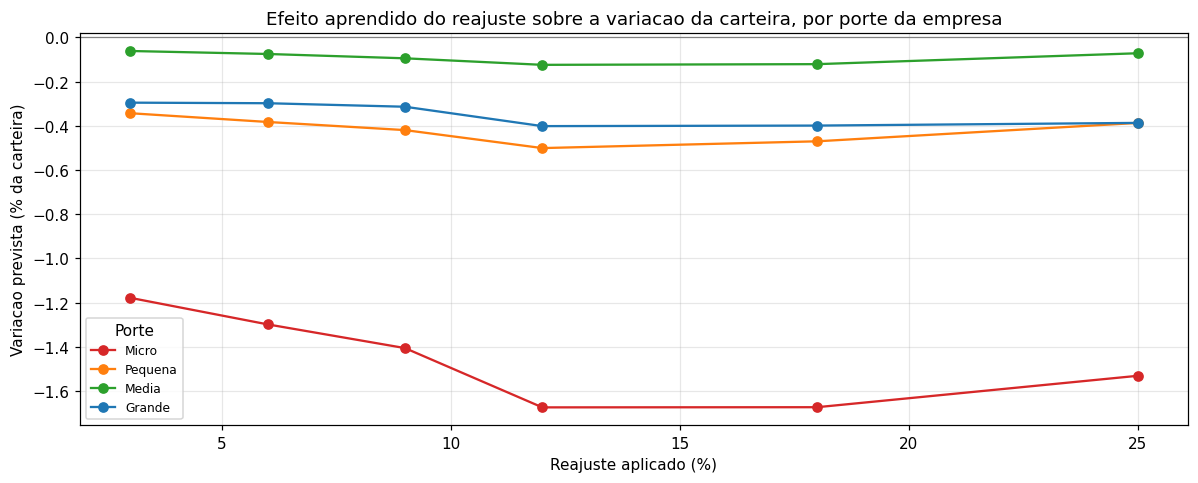

,Micro,Pequena,Media,Grande
3%,-1.178,-0.343,-0.062,-0.295
6%,-1.298,-0.383,-0.075,-0.298
9%,-1.405,-0.419,-0.095,-0.314
12%,-1.673,-0.501,-0.124,-0.402
18%,-1.672,-0.470,-0.121,-0.399
25%,-1.531,-0.387,-0.072,-0.387


In [18]:
# Efeito parcial do reajuste: variamos o percentual e observamos a previsao media, por porte.
# Medimos em % da carteira para que portes de tamanhos muito diferentes sejam comparaveis.
percentuais = [0.03, 0.06, 0.09, 0.12, 0.18, 0.25]
curvas = {}
for porte in ["Micro", "Pequena", "Media", "Grande"]:
    subconjunto = teste[teste.porte == porte]
    base = subconjunto[FEATURES].copy()
    base["eh_pos_reajuste"] = 1
    base["meses_desde_reajuste"] = 1              # coloca todas as carteiras logo apos o reajuste
    vidas = subconjunto["vidas_inicio_mes"].values
    curvas[porte] = [100 * float(np.mean(modelo_cat.predict(base.assign(reajuste_vigente=p)) / vidas))
                     for p in percentuais]

fig, ax = plt.subplots(figsize=(11, 4.5))
for (porte, valores), cor in zip(curvas.items(), ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]):
    ax.plot([100 * p for p in percentuais], valores, marker="o", color=cor, label=porte)
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Efeito aprendido do reajuste sobre a variacao da carteira, por porte da empresa")
ax.set_xlabel("Reajuste aplicado (%)"); ax.set_ylabel("Variacao prevista (% da carteira)")
ax.legend(fontsize=8, title="Porte")
plt.tight_layout(); plt.show()

pd.DataFrame(curvas, index=[f"{int(100*p)}%" for p in percentuais]).round(3)

> **Lendo o gráfico.** Esta é a saída que vai para a mesa de precificação, e ela responde a uma pergunta de negócio direta: **quanto de carteira eu perco por cada ponto de reajuste, em cada tipo de empresa?**
>
> A separação entre as curvas é o que mais salta. As empresas **Micro** perdem entre **1,2% e 1,7% da carteira** por mês no período pós-reajuste, enquanto as **Média** perdem cerca de **0,1%**, mais de dez vezes menos. **Pequena** e **Grande** ficam no meio. O modelo aprendeu, sem que ninguém tenha escrito a regra, a **interação reajuste vezes porte** que colocamos no gerador, e a hierarquia recuperada é a correta: quanto menor a empresa, mais sensível ao preço.
>
> As curvas também **descem** conforme o reajuste sobe, o que é a direção esperada, e **achatam a partir de 18%**. Esse achatamento merece honestidade interpretativa: reajustes acima de 18% são **raros na base**, então o modelo tem pouquíssima evidência naquela faixa e simplesmente repete o que aprendeu no último ponto com dados. É o mesmo limite de sempre, dito de outra forma: **o modelo não sabe nada sobre regiões onde não houve observação**. Extrapolar essa curva para um reajuste de 40% seria inventar.
>
> Para a gestão, a leitura prática é que o custo em vidas de um mesmo reajuste **não é uniforme na carteira**, e uma política de reajuste diferenciada por porte, dentro do que a regulação permite, tem efeito material sobre a retenção.


## Laboratório interativo: ajuste o seu modelo de boosting

Agora é a sua vez. Os controles abaixo cobrem os quatro hiperparâmetros que realmente decidem o resultado de um modelo de boosting. Usamos o LightGBM porque ele treina em fração de segundo, o que deixa a exploração fluida.

O gráfico mostra as curvas de erro de **treino** e de **validação** ao longo das árvores, com a linha verde marcando o ponto do early stopping. O título traz o MAE de teste, para você acompanhar as três leituras ao mesmo tempo.

Experimentos sugeridos:

- **`learning_rate` alto (0,3) e `num_leaves` alto (127)**: a curva de treino desce a pique e a de validação sobe logo depois de um mínimo raso. É o retrato do sobreajuste no boosting.
- **`learning_rate` baixo (0,01)**: a curva de validação desce muito devagar e talvez o teto de árvores não seja suficiente. Subajuste por falta de rodadas, e não por falta de capacidade.
- **`num_leaves` baixo (7) com muitas árvores**: árvores fracas somadas em grande número, o regime clássico do boosting, e costuma ser o melhor resultado.
- **`min_child_samples` alto (100)**: veja o erro de treino subir e a distância entre as duas curvas encolher. É regularização agindo.


In [19]:
try:
    from ipywidgets import interact, SelectionSlider, IntSlider
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False


def laboratorio_boosting(learning_rate=0.05, num_leaves=31, min_child_samples=20, n_estimators=800):
    modelo = lgb.LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate,
                               num_leaves=num_leaves, min_child_samples=min_child_samples,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                               random_state=SEMENTE, verbose=-1)
    modelo.fit(X_treino, y_treino,
               eval_set=[(X_treino, y_treino), (X_validacao, y_validacao)],
               eval_names=["treino", "validacao"], eval_metric="l1",
               callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    curva_tr = modelo.evals_result_["treino"]["l1"]
    curva_va = modelo.evals_result_["validacao"]["l1"]
    melhor = modelo.best_iteration_
    mae_te = metricas(y_teste, modelo.predict(X_teste))[0]

    fig, ax = plt.subplots(figsize=(11.5, 4.5))
    ax.plot(curva_tr, color="#1f77b4", lw=1.6, label="MAE treino")
    ax.plot(curva_va, color="#d62728", lw=1.6, label="MAE validacao")
    ax.axvline(melhor, color="#2ca02c", ls="--", lw=1.4, label=f"early stopping: {melhor} arvores")
    ax.axhline(5.034, color="#999999", ls=":", lw=1.2, label="referencia simples (5,03)")
    ax.axhline(3.163, color="#111111", ls=":", lw=1.2, label="piso do oraculo (3,16)")
    ax.set_ylim(0, 6.2)
    ax.set_title(f"lr={learning_rate}, num_leaves={num_leaves}, min folha={min_child_samples}   |   "
                 f"MAE validacao={min(curva_va):.3f}   MAE TESTE={mae_te:.3f}")
    ax.set_xlabel("Numero de arvores"); ax.set_ylabel("MAE (vidas)")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()


if _INTERATIVO:
    interact(
        laboratorio_boosting,
        learning_rate=SelectionSlider(options=[0.01, 0.03, 0.05, 0.1, 0.2, 0.3], value=0.05,
                                      description="learning_rate"),
        num_leaves=SelectionSlider(options=[7, 15, 31, 63, 127, 255], value=31, description="num_leaves"),
        min_child_samples=IntSlider(value=20, min=5, max=150, step=5, description="min folha"),
        n_estimators=SelectionSlider(options=[200, 400, 800, 1500], value=800, description="teto arvores"),
    )
else:
    print("ipywidgets indisponivel; exibindo dois cenarios estaticos.")
    laboratorio_boosting(0.30, 127, 20, 800)
    laboratorio_boosting(0.05, 15, 20, 800)

interactive(children=(SelectionSlider(description='learning_rate', index=2, options=(0.01, 0.03, 0.05, 0.1, 0.…

> **O que observar.** Na configuração padrão, a curva de validação encontra o mínimo em algumas centenas de árvores e o early stopping para pouco depois. Três coisas merecem atenção enquanto você mexe nos controles.
>
> A primeira é que a curva de **validação quase nunca é monótona**: ela desce, encontra um vale e começa a subir. **Esse vale é o modelo**, e tudo depois dele é ruído sendo memorizado. No bagging da aula anterior essa curva simplesmente achatava; aqui ela vira. É a assinatura do boosting.
>
> A segunda é o **acoplamento entre `learning_rate` e o número de árvores**. Reduza a taxa e o vale se desloca para a direita: o mesmo aprendizado, dividido em mais passos. Se você reduzir muito a taxa sem aumentar o teto de árvores, o modelo fica **inacabado**, e isso se vê porque a curva de validação ainda está descendo quando o gráfico termina.
>
> A terceira é que, por mais que você ajuste, **a linha do piso não é atravessada**. Você pode chegar perto de 4,1 ou 4,2, e nenhum ajuste vai levar a 3,2. Essa é a lição mais valiosa do laboratório: passado o ponto em que o modelo já capturou a estrutura, o esforço deve migrar do ajuste de hiperparâmetros para a **obtenção de dados novos**, que é o único caminho capaz de baixar o piso.


## Síntese, quando usar cada um, e o próximo passo

Esta aula fechou a família de árvores. Saímos de uma árvore isolada, passamos pelo bagging e chegamos ao boosting, aplicado a um problema que é o coração do planejamento da operadora: a evolução da carteira de beneficiários.

**O que o boosting é, em uma frase:** uma soma de correções, em que cada árvore rasa é treinada no erro que sobrou das anteriores, com passos deliberadamente pequenos.

**Os cinco resultados numéricos para levar:**

| Etapa                                 | MAE no teste | Leitura                              |
| ------------------------------------- | ------------ | ------------------------------------ |
| Carteira estável (não fazer nada)     | 5,29         | o custo de não ter modelo            |
| Média dos 3 últimos meses             | 5,03         | a referência simples a ser batida    |
| Melhor conjunto de features, boosting | **4,20**     | 44% do sinal aprendível capturado    |
| Média dos três modelos (ensemble)     | **4,14**     | combinar famílias sai quase de graça |
| Oráculo (piso do problema)            | 3,16         | o que sobra é sorteio de Poisson     |

**Como escolher entre as três bibliotecas.** Nenhuma das três é "a melhor". A decisão é de contexto:

| Situação                                                                          | Escolha indicada                                                              |
| --------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| Base média, muitas features numéricas, precisa de controle fino                   | **XGBoost**: regularização explícita, documentação madura, ecossistema enorme |
| Base grande (centenas de milhares de linhas ou mais), tempo é restrição           | **LightGBM**: GOSS e EFB foram feitos para isso                               |
| Muitas categóricas, sobretudo de **alta cardinalidade**, pouco tempo para ajustar | **CatBoost**: nativo, sem vazamento, bom quase na configuração padrão         |
| Você tem tempo de treinar mais de um                                              | **os três, e combine**: foi o melhor resultado desta aula                     |

**Quando usar boosting na operadora:** previsão de carteira por contrato, propensão a cancelamento (churn), volume de solicitações de autorização prévia por especialidade, previsão de sinistralidade por carteira, priorização de auditoria de contas. Em todos esses casos o dado é tabular, as variáveis cadastrais são categóricas e as interações importam, que é precisamente o terreno onde essa família domina.

**Limitações que precisam ficar registradas:**

- **Não extrapola.** Vimos isso custar 1.100 vidas na projeção agregada de seis meses. Para o total da operadora, um modelo de série temporal que projeta tendência (SARIMA, Prophet) é o instrumento adequado, e o boosting fica com a previsão por contrato.
- **Sobreajusta com facilidade** se `n_estimators` for tratado como um número a chutar. Early stopping com conjunto de validação separado não é opcional.
- **Vazamento é o inimigo silencioso.** Em painel, toda feature de histórico precisa de `shift` dentro do grupo, e toda média de alvo precisa ser calculada fora da amostra.
- **Importância global engana** quando o efeito é concentrado em poucos períodos, como o do reajuste. Efeitos parciais e recortes condicionais respondem melhor.
- **Não modela sequência longa de forma nativa.** O que o modelo sabe do passado é o que escrevemos como coluna. Se a dependência temporal for longa e complexa, a alternativa é uma arquitetura que aprende a sequência sozinha.

**É aí que entra o próximo módulo.** Todas as features de defasagem que construímos à mão (`variacao_lag1`, `media_variacao_3m`, `media_variacao_6m`) são tentativas de contar ao modelo o que aconteceu antes. Uma **LSTM** (Seção 9) inverte essa lógica: em vez de receber o passado resumido em colunas, ela recebe a **sequência inteira** e aprende, com seus portões de memória, o que vale lembrar e o que vale esquecer. É mais poderoso e mais caro, exige mais dados e mais cuidado, e é o assunto da próxima aula.

---

**Referências**

- Chen, T.; Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. _KDD_.
- Ke, G. et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. _NeurIPS_.
- Prokhorenkova, L. et al. (2018). CatBoost: unbiased boosting with categorical features. _NeurIPS_.
- Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. _The Annals of Statistics_.
- Hastie, T.; Tibshirani, R.; Friedman, J. (2009). _The Elements of Statistical Learning_, 2ª edição. Springer.
- Porto, B. M.; Fogliatto, F. S. (2024). Enhanced forecasting of emergency department patient arrivals using feature engineering.
